# QDP-Fed: Privacy-Utility-Communication Trade-offs in Federated Health-Risk Prediction

```
QDP-Fed: Privacy-Utility-Communication Trade-offs in Federated Health-Risk Prediction
======================================================================================
Reference pipeline -- empirical, privacy-accounted evaluation (not a new DP algorithm).

Datasets:
    - Fed-Heart-Disease (FLamby)  -- real multi-site clinical data
    - Fed-TCGA-BRCA     (FLamby)  -- real multi-site clinical data, 5-year event proxy label
    - Wisconsin Breast Cancer (sklearn, bundled) -- single-source, freely re-partitionable;
      used for the controlled non-IID robustness sweep (Dirichlet / sorted / random clients).

Models: FedAvg, FedProx, DP-FedProx (client-level DP), Q-DP-FedProx (+ 8-bit quantization),
plus Centralized-LR / Centralized-RF baselines (pooled data, upper-bound reference only).

Figures produced per dataset (heart, brca, wisconsin):
    1. fig_system_diagram              -- one-off, conceptual, no data (Figure 1)
    2. fig_client_prevalence           -- per-client N and label rate
    3. fig_main_comparison             -- AUC / PR-AUC / recall / MCC vs. model
    4. fig_convergence                 -- per-round validation AUC / PR-AUC
    5. fig_roc_curves                  -- ROC per model, held-out test
    6. fig_calibration_curves          -- reliability diagram + ECE
    7. fig_confusion_matrices          -- confusion matrix grid, val-selected threshold
    8. fig_privacy_utility_communication -- epsilon/communication vs. utility (heart, brca only)
    9. fig_noniid_robustness           -- Dirichlet/sorted/random partition sweep (wisconsin only)

Run:
    python qdp_fed_pipeline.py --smoke-test                     # rounds=3, seeds=1, sanity check
    python qdp_fed_pipeline.py --full-run --seeds 5 --rounds 30  # paper numbers + figures
    python qdp_fed_pipeline.py --full-run --datasets wisconsin   # no FLamby/network needed
```

## 0. Setup

Installs FLamby from GitHub (it isn't on PyPI). Wisconsin needs nothing here at all (bundled in scikit-learn).

In [1]:
# FLamby is NOT on PyPI -- `pip install flamby` silently fails (this is
# exactly what happened if you saw "FLamby not installed" below with no
# heart/brca results). It has to be installed from GitHub instead.
import os, subprocess, sys

if not os.path.isdir("FLamby"):
    subprocess.run(["git", "clone", "https://github.com/owkin/FLamby.git"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "FLamby[heart,tcga]"], check=True)
sys.path.insert(0, os.path.abspath("FLamby"))

# Optional: enables the Centralized-RF local-explanation figure.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=False)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'shap'], returncode=0)

### Download Fed-Heart-Disease (interactive, one-time)

Run this cell on its own and answer the license prompt (`y`). Fed-TCGA-BRCA needs no separate download -- its data ships inside the FLamby repo -- but it prompts the same way the first time it's loaded further down in the pipeline; just answer `y` there too when it comes up.

In [2]:
# Fed-Heart-Disease: small (~39KB), public UCI data. This MUST run as a
# normal in-kernel cell (not `!` / not subprocess) so the license prompt
# below can actually reach you -- a subprocess's input() has no connection
# to Jupyter's frontend and just crashes with EOFError. Type "y" when asked.
# One-time only; safe to re-run afterwards (no-op once downloaded).
%run FLamby/flamby/datasets/fed_heart_disease/dataset_creation_scripts/download.py --output-folder ./heart_disease_dataset

Have you taken the time to read and accept the data terms on the original website, available at the following link: https://archive-beta.ics.uci.edu/ml/datasets/heart+disease ? | (y/n)


 y


Saving license agreement
You may now proceed to download.

This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license.
See https://archive-beta.ics.uci.edu/ml/datasets/heart+disease.

Creators of the dataset:
  1. Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
  2. University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
  3. University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
  4. V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.

To cite this dataset, cite the following: Janosi, Andras, Steinbrunn, William, Pfisterer, Matthias, Detrano, Robert & M.D., M.D.. (1988). Heart Disease. UCI Machine Learning Repository.







In [3]:
import os
import sys
import json
import argparse
import warnings
import itertools
from dataclasses import dataclass, field, asdict
from typing import Optional

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# NumPy 2.0 removed the np.NaN alias; FLamby's *installed* loader code
# (fed_heart_disease/dataset.py) still uses it internally in some releases.
# Restore the alias before importing anything that touches FLamby.
if not hasattr(np, "NaN"):
    np.NaN = np.nan

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    f1_score,
    recall_score,
    precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
)
from scipy.stats import wilcoxon

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

HEART_NUM_CLIENTS = 4
BRCA_NUM_CLIENTS = 6
BRCA_EVENT_WINDOW_YEARS = 5  # disclosed proxy-label threshold; vary as a robustness check

# Optional: named features for the local-explanation (XAI) figures. Left as
# None because FLamby's raw tensors don't carry column names through the
# DataLoader path used above -- fill these in from FLamby's dataset docs
# (Fed-Heart-Disease: 13 UCI heart-disease features; Fed-TCGA-BRCA: ~39
# clinical covariates) if you want named bars instead of "feature_i".
HEART_FEATURE_NAMES = None
BRCA_FEATURE_NAMES = None


def _resolve_feature_names(explicit_names, d: int):
    if explicit_names is not None and len(explicit_names) == d:
        return list(explicit_names)
    return [f"feature_{i}" for i in range(d)]

## 0. Reproducibility

In [4]:
def set_seed(seed: int) -> np.random.Generator:
    return np.random.default_rng(seed)

## 1. Data loading (FLamby Fed-Heart-Disease, Fed-TCGA-BRCA + external Wisconsin)

In [5]:
def _try_import_flamby():
    try:
        from flamby.datasets.fed_heart_disease import FedHeartDisease  # noqa
        from flamby.datasets.fed_tcga_brca import FedTcgaBrca  # noqa
        return True
    except Exception:
        return False


HAS_FLAMBY = _try_import_flamby()


def _extract_flamby_feature_names(ds, expected_dim: int):
    """
    Best-effort: several FLamby dataset objects keep the original pandas
    DataFrame around as `self.data` -- confirmed directly from FLamby's
    source for TcgaBrcaRaw/FedTcgaBrca (its docstring states `data`: "pandas
    dataframe containing the data for the all the patients", sliced as
    `self.data.iloc[idx, 1:40]` for the 39 covariates). Other FLamby dataset
    classes follow the same internal pattern.

    Only used when the resulting column count matches the tensor's feature
    dimension EXACTLY -- if the schema doesn't match what we expect (id/label
    columns named differently, a FLamby version with a different layout),
    this returns None and the caller falls back to generic "feature_i"
    names rather than risk mislabeling a clinical feature.
    """
    df = getattr(ds, "data", None)
    if df is None or not hasattr(df, "columns"):
        return None

    drop_like = {"pid", "id", "patient_id", "e", "t", "time", "event",
                 "target", "num", "label", "y"}
    candidate_cols = [c for c in df.columns if str(c).strip().lower() not in drop_like]
    if len(candidate_cols) == expected_dim:
        return [str(c) for c in candidate_cols]

    # Fallback matching FLamby's own documented slice convention for
    # Fed-TCGA-BRCA: column 0 is an id, the next `expected_dim` columns are
    # the covariates, and whatever follows is the label.
    if len(df.columns) >= expected_dim + 1:
        sliced = list(df.columns[1:1 + expected_dim])
        if len(sliced) == expected_dim:
            return [str(c) for c in sliced]
    return None


def load_flamby_heart(train: bool):
    """Returns per-client (X, y) lists for Fed-Heart-Disease, plus feature
    names extracted from the underlying dataframe when possible (None if
    the schema can't be matched safely -- see _extract_flamby_feature_names)."""
    from flamby.datasets.fed_heart_disease import FedHeartDisease
    from torch.utils.data import DataLoader

    clients_X, clients_y = [], []
    feature_names = None
    for c in range(HEART_NUM_CLIENTS):
        ds = FedHeartDisease(center=c, train=train)
        dl = DataLoader(ds, batch_size=len(ds), shuffle=False, num_workers=0)
        X, y = next(iter(dl))
        clients_X.append(X.numpy().astype(np.float64))
        clients_y.append(y.numpy().astype(np.float64).reshape(-1))
        if feature_names is None:
            feature_names = _extract_flamby_feature_names(ds, X.shape[1])
    return clients_X, clients_y, feature_names


def load_flamby_brca(train: bool, window_years: float = BRCA_EVENT_WINDOW_YEARS):
    """
    Returns per-client (X, y_binary) lists for Fed-TCGA-BRCA, plus feature
    names extracted from the underlying dataframe when possible.

    FLamby's own docstring: "Pytorch dataset containing all the clinical
    features and (event, time) information" -- column 0 is the binary event
    indicator E, column 1 is the continuous survival time T in days. Getting
    this backwards makes `event_ == 1` almost never true and silently
    produces near-all-zero labels (NaN AUC, meaningless F1/accuracy) with NO
    crash anywhere -- this is exactly the bug this loader guards against.
    """
    from flamby.datasets.fed_tcga_brca import FedTcgaBrca
    from torch.utils.data import DataLoader

    clients_X, clients_y = [], []
    feature_names = None
    for c in range(BRCA_NUM_CLIENTS):
        ds = FedTcgaBrca(center=c, train=train)
        dl = DataLoader(ds, batch_size=len(ds), shuffle=False, num_workers=0)
        X, y = next(iter(dl))
        y_np = y.numpy()
        event_, time_ = y_np[:, 0], y_np[:, 1]  # (event, time) -- see docstring above
        y_bin = ((event_ == 1) & (time_ <= window_years * 365.25)).astype(np.float64)
        clients_X.append(X.numpy().astype(np.float64))
        clients_y.append(y_bin)
        if feature_names is None:
            feature_names = _extract_flamby_feature_names(ds, X.shape[1])

    overall_rate = float(np.mean(np.concatenate(clients_y)))
    # Sanity guard against a silent column-order regression across FLamby
    # versions. Published Fed-TCGA-BRCA event rate is ~14%; band is wide but sane.
    assert 0.03 < overall_rate < 0.6, (
        f"Fed-TCGA-BRCA event rate looks implausible ({overall_rate:.3f}). "
        "This usually means the (event, time) column order changed -- "
        "check flamby.datasets.fed_tcga_brca.dataset before trusting results."
    )
    return clients_X, clients_y, feature_names


def load_wisconsin_pooled():
    """Single-source tabular dataset (UCI Breast Cancer Wisconsin Diagnostic,
    bundled in scikit-learn). Not federated by construction -- we partition
    it ourselves below to run controlled non-IID robustness experiments."""
    data = load_breast_cancer()
    X = data.data.astype(np.float64)
    y = data.target.astype(np.float64)  # 1 = benign in sklearn's encoding
    y = 1.0 - y  # flip so 1 = malignant (clinically "positive"/at-risk class)
    feature_names = list(data.feature_names)
    return X, y, feature_names

## 2. Client partitioning (Wisconsin external dataset only)

In [6]:
def partition_random_balanced(y: np.ndarray, num_clients: int, rng: np.random.Generator):
    idx = rng.permutation(len(y))
    return [idx[i::num_clients] for i in range(num_clients)]


def partition_sorted_by_feature(X: np.ndarray, feature_idx: int, num_clients: int,
                                 rng: np.random.Generator):
    """Structured covariate shift: sort by one feature, chunk into clients
    (with a small shuffle within chunks so clients aren't perfectly ordered)."""
    order = np.argsort(X[:, feature_idx])
    chunks = np.array_split(order, num_clients)
    return [rng.permutation(c) for c in chunks]


def partition_dirichlet(y: np.ndarray, num_clients: int, alpha: float,
                         rng: np.random.Generator, min_size: int = 5):
    """Standard Dirichlet label-skew partition (Hsu et al., 2019). Retries
    with fresh draws if a degenerate split leaves a client too small; this
    reshuffles which *draw* is used, never which patients end up positive,
    so no records are duplicated or moved to satisfy the constraint."""
    classes = np.unique(y)
    for _ in range(50):
        client_idx = [[] for _ in range(num_clients)]
        for c in classes:
            idx_c = np.where(y == c)[0]
            rng.shuffle(idx_c)
            proportions = rng.dirichlet(alpha=np.repeat(alpha, num_clients))
            splits = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
            parts = np.split(idx_c, splits)
            for k in range(num_clients):
                client_idx[k].extend(parts[k].tolist())
        sizes = [len(c) for c in client_idx]
        if min(sizes) >= min_size:
            return [np.array(c) for c in client_idx]
    return [np.array(c) for c in client_idx]


PARTITION_STRATEGIES = {
    "random": lambda X, y, K, rng: partition_random_balanced(y, K, rng),
    "sorted": lambda X, y, K, rng: partition_sorted_by_feature(X, 0, K, rng),  # "mean radius"
    "dirichlet_1.0": lambda X, y, K, rng: partition_dirichlet(y, K, 1.0, rng),
    "dirichlet_0.5": lambda X, y, K, rng: partition_dirichlet(y, K, 0.5, rng),
    "dirichlet_0.1": lambda X, y, K, rng: partition_dirichlet(y, K, 0.1, rng),
}

## 3. Preprocessing (split-first, client-local)

In [7]:
@dataclass
class ClientSplit:
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray


def make_client_splits(clients_X_train_full, clients_y_train_full,
                        clients_X_test, clients_y_test,
                        val_fraction: float, seed: int):
    """
    Splits each client's *training* portion into local train/val (stratified
    where possible). The provided test partition is left untouched. Scalers
    are fit per client on that client's train fold only, and applied to that
    client's val/test folds -- never fit on pooled or held-out data.
    """
    splits = []
    for X_tr_full, y_tr_full, X_te, y_te in zip(
        clients_X_train_full, clients_y_train_full, clients_X_test, clients_y_test
    ):
        n_pos = int(y_tr_full.sum())
        n_neg = len(y_tr_full) - n_pos
        stratify = y_tr_full if (n_pos >= 2 and n_neg >= 2) else None
        if len(X_tr_full) < 6 or stratify is None:
            X_tr, y_tr = X_tr_full, y_tr_full
            X_val, y_val = X_tr_full, y_tr_full
        else:
            X_tr, X_val, y_tr, y_val = train_test_split(
                X_tr_full, y_tr_full, test_size=val_fraction,
                stratify=stratify, random_state=seed,
            )
        scaler = StandardScaler().fit(X_tr)
        splits.append(ClientSplit(
            X_train=scaler.transform(X_tr), y_train=y_tr,
            X_val=scaler.transform(X_val), y_val=y_val,
            X_test=scaler.transform(X_te), y_test=y_te,
        ))
    return splits


def pooled(splits, attr: str):
    return np.concatenate([getattr(cs, attr) for cs in splits])

## 4. Local model + FedAvg / FedProx / client-level DP / 8-bit quantization

In [8]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))


def class_weights(y: np.ndarray):
    """Balanced class weights -- used INSTEAD OF resampling for tiny/zero-
    positive clients, so no patient record is duplicated to hit a minimum
    positive count."""
    n = len(y)
    n_pos = max(int(y.sum()), 1)
    n_neg = max(n - n_pos, 1)
    w_pos = n / (2.0 * n_pos)
    w_neg = n / (2.0 * n_neg)
    return np.where(y == 1, w_pos, w_neg)


def local_train_logreg(X, y, w_global, b_global, epochs, lr, mu, l2=1e-4):
    """One client's local training round. Returns the UPDATE (dw, db), i.e.
    the change relative to the global model it started from -- this is the
    object that gets clipped/noised/quantized for transmission, never the
    raw dataset or raw gradients on individual examples."""
    w, b = w_global.copy(), b_global
    sw = class_weights(y)
    n = len(y)
    for _ in range(epochs):
        z = X @ w + b
        p = sigmoid(z)
        err = (p - y) * sw
        grad_w = (X.T @ err) / n + l2 * w + mu * (w - w_global)  # FedProx term
        grad_b = np.mean(err)
        w -= lr * grad_w
        b -= lr * grad_b
    return w - w_global, b - b_global


def clip_update(dw, db, clip_norm):
    update_norm = np.sqrt(np.sum(dw ** 2) + db ** 2)
    coef = min(1.0, clip_norm / (update_norm + 1e-12))
    return dw * coef, db * coef, update_norm


def quantize(arr, bits=8):
    mn, mx = float(arr.min()), float(arr.max())
    scale = (mx - mn) / (2 ** bits - 1) if (mx - mn) > 0 else 1e-12
    q = np.round((arr - mn) / scale).astype(np.uint8)
    return q, scale, mn


def dequantize(q, scale, mn):
    return q.astype(np.float64) * scale + mn


def payload_bytes(dw, db, quantized: bool):
    """Bytes needed to transmit one client's update this round -- used for
    the communication-cost figure. 8-bit path pays a small fixed overhead
    for the two float32 dequantization parameters (scale, min-value)."""
    n_params = dw.size + 1  # + bias
    if not quantized:
        return n_params * 4  # float32
    return n_params * 1 + 2 * 4  # uint8 payload + (scale, min) as float32


# ---- Privacy accounting (conservative RDP, no subsampling amplification) --

def rdp_gaussian(sigma, alpha):
    """RDP of the Gaussian mechanism at order alpha, for a mechanism whose
    noise std equals `sigma` times its L2 sensitivity (the standard
    "noise-multiplier" parameterization used by DP-SGD/Opacus)."""
    return alpha / (2.0 * sigma ** 2)


def rdp_to_eps(rdp_per_round_list, delta, alphas=None):
    """Composes RDP across rounds (simple additivity) and converts to
    (epsilon, delta) via the standard RDP->DP conversion, minimized over
    alpha. No subsampling amplification is assumed anywhere -- this is
    cross-silo FL with full client participation per round."""
    if alphas is None:
        alphas = [1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))
    total_rdp = {a: 0.0 for a in alphas}
    for sigma in rdp_per_round_list:
        if sigma <= 0:
            continue
        for a in alphas:
            total_rdp[a] += rdp_gaussian(sigma, a)
    best_eps = float("inf")
    for a in alphas:
        eps = total_rdp[a] + np.log(1.0 / delta) / (a - 1.0)
        best_eps = min(best_eps, eps)
    return best_eps


def try_opacus_cross_check(sigma, rounds, delta):
    """Best-effort cross-check against Opacus's RDP accountant, if installed.
    Never blocks the pipeline; returns None if Opacus is unavailable or its
    API doesn't match. Report both numbers in the appendix if they agree."""
    try:
        from opacus.accountants.analysis.rdp import compute_rdp, get_privacy_spent
        alphas = [1 + x / 10.0 for x in range(1, 100)] + list(range(12, 64))
        rdp = compute_rdp(q=1.0, noise_multiplier=sigma, steps=rounds, orders=alphas)
        eps, _ = get_privacy_spent(orders=alphas, rdp=rdp, delta=delta)
        return float(eps)
    except Exception:
        return None


# ---- One federated round --------------------------------------------------

@dataclass
class FedConfig:
    name: str
    mu: float = 0.0          # FedProx proximal weight
    dp: bool = False
    sigma: float = 0.0       # DP noise multiplier
    clip_norm: float = 1.0
    quantize_bits: Optional[int] = None
    local_epochs: int = 5
    lr: float = 0.1


CONFIGS = {
    "FedAvg":       FedConfig(name="FedAvg"),
    "FedProx":      FedConfig(name="FedProx",      mu=0.05),
    "DP-FedProx":   FedConfig(name="DP-FedProx",   mu=0.05, dp=True, sigma=1.5, clip_norm=1.0),
    "Q-DP-FedProx": FedConfig(name="Q-DP-FedProx", mu=0.05, dp=True, sigma=1.5, clip_norm=1.0,
                               quantize_bits=8),
}


def run_federated(splits: list, config: FedConfig, rounds: int, rng: np.random.Generator,
                   track_history: bool = False, history_every: int = 1):
    """
    Runs `rounds` rounds of federated averaging under `config`.

    track_history=False (default): returns (w, b, sigma_per_round, uplink_bytes_per_round)
    -- unchanged 4-tuple, so every existing caller keeps working exactly as before.

    track_history=True: additionally evaluates the pooled validation set every
    `history_every` rounds and returns a 5th element, `history` (list of dicts
    {round, val_auc, val_pr_auc}), used only for the convergence figure.
    """
    d = splits[0].X_train.shape[1]
    K = len(splits)
    w, b = np.zeros(d), 0.0
    sigma_per_round = []
    uplink_bytes_per_round = []
    history = [] if track_history else None

    if track_history:
        X_val_pooled = pooled(splits, "X_val")
        y_val_pooled = pooled(splits, "y_val")
        val_is_single_class = len(np.unique(y_val_pooled)) < 2

    for r in range(rounds):
        agg_dw = np.zeros(d)
        agg_db = 0.0
        round_bytes = 0
        for cs in splits:
            dw, db = local_train_logreg(
                cs.X_train, cs.y_train, w, b,
                epochs=config.local_epochs, lr=config.lr, mu=config.mu,
            )
            if config.dp:
                dw, db, _ = clip_update(dw, db, config.clip_norm)
                # DP-FedAvg noise: sensitivity of the K-client AVERAGE is
                # clip_norm / K, so noise std = sigma * clip_norm / K keeps
                # the effective noise multiplier equal to `sigma` (see
                # rdp_gaussian's parameterization above).
                noise_std = config.sigma * config.clip_norm / K
                dw = dw + rng.normal(0, noise_std, size=dw.shape)
                db = db + float(rng.normal(0, noise_std))

            if config.quantize_bits:
                q_w, sc_w, mn_w = quantize(dw, config.quantize_bits)
                dw = dequantize(q_w, sc_w, mn_w)
                q_b, sc_b, mn_b = quantize(np.array([db]), config.quantize_bits)
                db = float(dequantize(q_b, sc_b, mn_b)[0])
                round_bytes += payload_bytes(dw, db, quantized=True)
            else:
                round_bytes += payload_bytes(dw, db, quantized=False)

            agg_dw += dw / K
            agg_db += db / K

        w = w + agg_dw
        b = b + agg_db
        sigma_per_round.append(config.sigma if config.dp else 0.0)
        uplink_bytes_per_round.append(round_bytes)

        if track_history and ((r + 1) % history_every == 0 or r == rounds - 1):
            if val_is_single_class:
                auc_v, prauc_v = np.nan, np.nan
            else:
                probs_val = sigmoid(X_val_pooled @ w + b)
                auc_v = float(roc_auc_score(y_val_pooled, probs_val))
                prauc_v = float(average_precision_score(y_val_pooled, probs_val))
            history.append(dict(round=r + 1, val_auc=auc_v, val_pr_auc=prauc_v))

    if track_history:
        return w, b, sigma_per_round, uplink_bytes_per_round, history
    return w, b, sigma_per_round, uplink_bytes_per_round


def collect_convergence(splits: list, rounds: int, seed: int,
                         config_names=("FedAvg", "FedProx", "DP-FedProx", "Q-DP-FedProx")):
    """Re-runs each config with per-round validation tracking on for the
    convergence figure. Kept as a separate pass (rather than always tracking
    inside run_one_dataset) so the main multi-seed sweep pays no extra cost."""
    rows = []
    for cfg_name in config_names:
        cfg = CONFIGS[cfg_name]
        rng = set_seed(seed)
        _, _, _, _, history = run_federated(splits, cfg, rounds, rng, track_history=True)
        for h in history:
            rows.append(dict(model=cfg_name, **h))
    return pd.DataFrame(rows)

## 5. Evaluation (metrics, threshold selection, calibration)

In [9]:
def select_threshold_on_val(w, b, X_val, y_val):
    """Max-F1 threshold search on the VALIDATION set only. Applied once to
    test -- test is never touched for threshold selection."""
    probs = sigmoid(X_val @ w + b)
    if y_val.sum() == 0 or y_val.sum() == len(y_val):
        return 0.5
    thresholds = np.unique(np.clip(probs, 1e-6, 1 - 1e-6))
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t


def expected_calibration_error(probs, y, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i + 1] if i < n_bins - 1 else probs <= bins[i + 1])
        if mask.sum() == 0:
            continue
        conf = probs[mask].mean()
        acc = y[mask].mean()
        ece += (mask.sum() / len(y)) * abs(acc - conf)
    return float(ece)


def evaluate(w, b, X, y, threshold):
    probs = sigmoid(X @ w + b)
    preds = (probs >= threshold).astype(int)
    out = dict(
        auc=np.nan, pr_auc=np.nan,
        recall=np.nan, precision=np.nan, specificity=np.nan,
        f1=np.nan, mcc=np.nan, balanced_accuracy=np.nan,
        brier=np.nan, ece=np.nan,
    )
    if len(np.unique(y)) < 2:
        # A degenerate (single-class) fold: AUC/PR-AUC are undefined by
        # definition -- report NaN honestly rather than a misleading 0/1.
        out["brier"] = float(brier_score_loss(y, probs))
        return out
    out["auc"] = float(roc_auc_score(y, probs))
    out["pr_auc"] = float(average_precision_score(y, probs))
    out["recall"] = float(recall_score(y, preds, zero_division=0))
    out["precision"] = float(precision_score(y, preds, zero_division=0))
    tn, fp, fn, tp = confusion_matrix(y, preds, labels=[0, 1]).ravel()
    out["specificity"] = float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan
    out["f1"] = float(f1_score(y, preds, zero_division=0))
    out["mcc"] = float(matthews_corrcoef(y, preds)) if len(np.unique(preds)) > 1 else 0.0
    out["balanced_accuracy"] = float(balanced_accuracy_score(y, preds))
    out["brier"] = float(brier_score_loss(y, probs))
    out["ece"] = expected_calibration_error(probs, y)
    return out


def centralized_baselines(splits: list, seed: int):
    """Returns (results, preds) -- `preds` carries the raw test probabilities
    (+ chosen threshold) per baseline model, for the ROC/calibration/confusion
    figures alongside the federated models."""
    X_tr = pooled(splits, "X_train"); y_tr = pooled(splits, "y_train")
    X_val = pooled(splits, "X_val"); y_val = pooled(splits, "y_val")
    X_te = pooled(splits, "X_test"); y_te = pooled(splits, "y_test")

    results, preds = {}, {}

    lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
    lr.fit(X_tr, y_tr)
    w, b = lr.coef_.ravel(), float(lr.intercept_[0])
    t = select_threshold_on_val(w, b, X_val, y_val)
    results["Centralized-LR"] = evaluate(w, b, X_te, y_te, t)
    preds["Centralized-LR"] = dict(probs=sigmoid(X_te @ w + b), y=y_te, threshold=t,
                                    kind="linear", w=w, b=b)

    rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                 random_state=seed, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    probs_val = rf.predict_proba(X_val)[:, 1]
    probs_te = rf.predict_proba(X_te)[:, 1]
    if 0 < y_val.sum() < len(y_val):
        thresholds = np.unique(np.clip(probs_val, 1e-6, 1 - 1e-6))
        best_t, best_f1 = 0.5, -1.0
        for tt in thresholds:
            f1v = f1_score(y_val, (probs_val >= tt).astype(int), zero_division=0)
            if f1v > best_f1:
                best_f1, best_t = f1v, tt
    else:
        best_t = 0.5
    preds_te = (probs_te >= best_t).astype(int)
    r = dict(auc=np.nan, pr_auc=np.nan, recall=np.nan, precision=np.nan,
              specificity=np.nan, f1=np.nan, mcc=np.nan,
              balanced_accuracy=np.nan, brier=np.nan, ece=np.nan)
    if len(np.unique(y_te)) > 1:
        r["auc"] = float(roc_auc_score(y_te, probs_te))
        r["pr_auc"] = float(average_precision_score(y_te, probs_te))
        r["recall"] = float(recall_score(y_te, preds_te, zero_division=0))
        r["precision"] = float(precision_score(y_te, preds_te, zero_division=0))
        tn, fp, fn, tp = confusion_matrix(y_te, preds_te, labels=[0, 1]).ravel()
        r["specificity"] = float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan
        r["f1"] = float(f1_score(y_te, preds_te, zero_division=0))
        r["mcc"] = float(matthews_corrcoef(y_te, preds_te)) if len(np.unique(preds_te)) > 1 else 0.0
        r["balanced_accuracy"] = float(balanced_accuracy_score(y_te, preds_te))
    r["brier"] = float(brier_score_loss(y_te, probs_te))
    r["ece"] = expected_calibration_error(probs_te, y_te)
    results["Centralized-RF"] = r
    preds["Centralized-RF"] = dict(probs=probs_te, y=y_te, threshold=best_t,
                                    kind="tree", model=rf)

    return results, preds

## 6. Experiment driver (multi-seed runs, significance tests)

In [10]:
METRIC_COLS = ["auc", "pr_auc", "recall", "precision", "specificity", "f1",
               "mcc", "balanced_accuracy", "brier", "ece"]

FEDERATED_MODEL_NAMES = ("FedAvg", "FedProx", "DP-FedProx", "Q-DP-FedProx")


def select_best_federated_model(df: pd.DataFrame, metric: str = "pr_auc",
                                 candidates=FEDERATED_MODEL_NAMES):
    """
    Best-performing model among the federated, privacy-accounted configs
    ONLY. Centralized-LR/RF are deliberately excluded from this selection:
    they train on pooled raw data with no clipping, noise, or quantization,
    so they carry no privacy budget at all and aren't a fair "best" pick in
    a paper about privacy-utility trade-offs -- comparing them to DP models
    on raw utility alone would silently favor the non-private option every
    time. They still appear in fig_main_comparison as a non-private
    reference ceiling; nowhere else.
    """
    means = {}
    for m in candidates:
        vals = df[df.model == m][metric].dropna().values
        means[m] = float(np.mean(vals)) if len(vals) else -np.inf
    return max(means, key=means.get)


def run_one_dataset(dataset_name: str, clients_X_train, clients_y_train,
                     clients_X_test, clients_y_test, seeds: int, rounds: int,
                     val_fraction: float, out_dir: str):
    """Returns (df, summary, pred_store, X_test_last). `pred_store` holds, for
    the LAST seed only, {model_name: {probs, y, threshold, kind, ...}} on the
    pooled test set -- used for the ROC / calibration / confusion-matrix /
    local-explanation figures. `kind` is "linear" (carries w, b) or "tree"
    (carries the fitted RF). `X_test_last` is the pooled test feature matrix
    that produced those predictions (same scaling for every model, since all
    models in a seed share the same ClientSplit objects)."""
    os.makedirs(out_dir, exist_ok=True)
    rows = []
    pred_store = {}
    X_test_last = None

    for seed in range(seeds):
        rng = set_seed(seed)
        splits = make_client_splits(clients_X_train, clients_y_train,
                                     clients_X_test, clients_y_test,
                                     val_fraction=val_fraction, seed=seed)

        for cfg_name, cfg in CONFIGS.items():
            w, b, sigmas, comm_bytes = run_federated(splits, cfg, rounds, rng)
            X_val = pooled(splits, "X_val"); y_val = pooled(splits, "y_val")
            X_te = pooled(splits, "X_test"); y_te = pooled(splits, "y_test")
            t = select_threshold_on_val(w, b, X_val, y_val)
            metrics = evaluate(w, b, X_te, y_te, t)
            eps = rdp_to_eps(sigmas, delta=1e-5) if cfg.dp else np.nan
            metrics.update(dict(dataset=dataset_name, model=cfg_name, seed=seed,
                                 epsilon=eps, uplink_bytes_total=int(np.sum(comm_bytes)),
                                 uplink_mb_mean_per_round=np.mean(comm_bytes) / 1e6))
            rows.append(metrics)
            if seed == seeds - 1:
                pred_store[cfg_name] = dict(probs=sigmoid(X_te @ w + b), y=y_te, threshold=t,
                                             kind="linear", w=w, b=b)

        base, base_preds = centralized_baselines(splits, seed=seed)
        for name, m in base.items():
            m.update(dict(dataset=dataset_name, model=name, seed=seed,
                           epsilon=np.nan, uplink_bytes_total=np.nan,
                           uplink_mb_mean_per_round=np.nan))
            rows.append(m)
        if seed == seeds - 1:
            pred_store.update(base_preds)
            X_test_last = X_te

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(out_dir, f"{dataset_name}_raw_results.csv"), index=False)

    summary = df.groupby("model")[METRIC_COLS + ["epsilon", "uplink_mb_mean_per_round"]].agg(
        ["mean", "std"])
    summary.columns = ["_".join(c) for c in summary.columns]
    summary.to_csv(os.path.join(out_dir, f"{dataset_name}_summary.csv"))

    sig_lines = []
    chain = ["FedAvg", "FedProx", "DP-FedProx", "Q-DP-FedProx"]
    for a, b_ in zip(chain[:-1], chain[1:]):
        va = df[df.model == a].sort_values("seed")["auc"].values
        vb = df[df.model == b_].sort_values("seed")["auc"].values
        if len(va) == len(vb) and len(va) >= 5 and not (np.any(np.isnan(va)) or np.any(np.isnan(vb))):
            try:
                stat, p = wilcoxon(va, vb)
            except ValueError:
                p = np.nan
        else:
            p = np.nan
        sig_lines.append(f"{a}_vs_{b_}: wilcoxon p={p}, mean_auc_diff={np.nanmean(vb) - np.nanmean(va):.4f} (n_seeds={len(va)})")
    with open(os.path.join(out_dir, f"{dataset_name}_significance.txt"), "w") as f:
        f.write("\n".join(sig_lines))

    return df, summary, pred_store, X_test_last


def run_privacy_utility_sweep(clients_X_train, clients_y_train, clients_X_test,
                               clients_y_test, sigma_values, rounds: int,
                               seed: int, val_fraction: float):
    rng = set_seed(seed)
    splits = make_client_splits(clients_X_train, clients_y_train,
                                 clients_X_test, clients_y_test,
                                 val_fraction=val_fraction, seed=seed)
    rows = []
    for sigma in sigma_values:
        cfg = FedConfig(name=f"sigma={sigma}", mu=0.05, dp=(sigma > 0),
                         sigma=sigma, clip_norm=1.0, quantize_bits=8)
        w, b, sigmas, comm_bytes = run_federated(splits, cfg, rounds, rng)
        X_val = pooled(splits, "X_val"); y_val = pooled(splits, "y_val")
        X_te = pooled(splits, "X_test"); y_te = pooled(splits, "y_test")
        t = select_threshold_on_val(w, b, X_val, y_val)
        m = evaluate(w, b, X_te, y_te, t)
        eps = rdp_to_eps(sigmas, delta=1e-5) if sigma > 0 else np.nan
        rows.append(dict(sigma=sigma, epsilon=eps,
                          uplink_mb_mean=np.mean(comm_bytes) / 1e6, **m))
    return pd.DataFrame(rows)


def run_noniid_robustness(X, y, num_clients: int, seeds: int, rounds: int,
                           val_fraction: float, out_dir: str):
    rows = []
    for strat_name, strat_fn in PARTITION_STRATEGIES.items():
        for seed in range(seeds):
            rng = set_seed(seed)
            client_idx = strat_fn(X, y, num_clients, rng)
            cX = [X[idx] for idx in client_idx]
            cy = [y[idx] for idx in client_idx]
            cX_tr, cy_tr, cX_te, cy_te = [], [], [], []
            for Xi, yi in zip(cX, cy):
                classes, counts = np.unique(yi, return_counts=True)
                can_stratify = len(classes) >= 2 and counts.min() >= 2 and len(yi) >= 10
                if len(yi) < 10:
                    cX_tr.append(Xi); cy_tr.append(yi)
                    cX_te.append(Xi); cy_te.append(yi)
                    continue
                Xtr, Xte, ytr, yte = train_test_split(
                    Xi, yi, test_size=0.2,
                    stratify=yi if can_stratify else None, random_state=seed)
                cX_tr.append(Xtr); cy_tr.append(ytr)
                cX_te.append(Xte); cy_te.append(yte)

            splits = make_client_splits(cX_tr, cy_tr, cX_te, cy_te,
                                         val_fraction=val_fraction, seed=seed)
            for cfg_name in ["FedAvg", "Q-DP-FedProx"]:
                cfg = CONFIGS[cfg_name]
                w, b, sigmas, _ = run_federated(splits, cfg, rounds, rng)
                X_val = pooled(splits, "X_val"); y_val = pooled(splits, "y_val")
                X_te = pooled(splits, "X_test"); y_te = pooled(splits, "y_test")
                t = select_threshold_on_val(w, b, X_val, y_val)
                m = evaluate(w, b, X_te, y_te, t)
                m.update(dict(partition=strat_name, model=cfg_name, seed=seed))
                rows.append(m)
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(out_dir, "wisconsin_noniid_robustness.csv"), index=False)
    return df

## 7. Figures

In [11]:
def fig_main_comparison(df: pd.DataFrame, dataset_name: str, out_dir: str):
    metrics = ["auc", "pr_auc", "recall", "mcc"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharex=False)
    models = [m for m in ["FedAvg", "FedProx", "DP-FedProx", "Q-DP-FedProx",
                           "Centralized-LR", "Centralized-RF"] if m in df.model.unique()]
    for ax, metric in zip(axes, metrics):
        means, cis = [], []
        for m in models:
            vals = df[df.model == m][metric].dropna().values
            means.append(np.mean(vals) if len(vals) else np.nan)
            n = max(len(vals), 1)
            cis.append(1.96 * np.std(vals) / np.sqrt(n) if len(vals) else 0.0)
        ax.errorbar(range(len(models)), means, yerr=cis, fmt="o", capsize=4)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha="right", fontsize=8)
        ax.set_title(metric.upper())
        ax.grid(alpha=0.3)
    fig.suptitle(f"{dataset_name}: main comparison (mean \u00b1 95% CI over seeds)")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_fig_main_comparison.png"), dpi=150)
    plt.close(fig)


def fig_privacy_utility_communication(df_sweep: pd.DataFrame, dataset_name: str, out_dir: str):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(df_sweep["epsilon"], df_sweep["pr_auc"], "o-")
    axes[0].set_xlabel("epsilon"); axes[0].set_ylabel("test PR-AUC")
    axes[0].set_title("Privacy vs. utility")
    axes[1].plot(df_sweep["uplink_mb_mean"], df_sweep["pr_auc"], "o-")
    axes[1].set_xlabel("uplink MB / round (mean)"); axes[1].set_ylabel("test PR-AUC")
    axes[1].set_title("Communication vs. utility")
    axes[2].plot(df_sweep["sigma"], df_sweep["pr_auc"], "o-")
    axes[2].set_xlabel("noise multiplier (sigma)"); axes[2].set_ylabel("test PR-AUC")
    axes[2].set_title("Noise vs. utility")
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.suptitle(f"{dataset_name}: privacy-utility-communication trade-off")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_fig_privacy_utility_comm.png"), dpi=150)
    plt.close(fig)


def fig_noniid_robustness(df: pd.DataFrame, out_dir: str):
    partitions = list(PARTITION_STRATEGIES.keys())
    fig, ax = plt.subplots(figsize=(8, 5))
    width = 0.35
    x = np.arange(len(partitions))
    for i, model in enumerate(["FedAvg", "Q-DP-FedProx"]):
        means = [df[(df.partition == p) & (df.model == model)]["pr_auc"].mean() for p in partitions]
        stds = [df[(df.partition == p) & (df.model == model)]["pr_auc"].std() for p in partitions]
        ax.bar(x + (i - 0.5) * width, means, width, yerr=stds, capsize=4, label=model)
    ax.set_xticks(x)
    ax.set_xticklabels(partitions, rotation=30, ha="right")
    ax.set_ylabel("test PR-AUC")
    ax.set_title("Non-IID robustness (Wisconsin, synthetic clients)")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "wisconsin_fig_noniid_robustness.png"), dpi=150)
    plt.close(fig)


def fig_client_prevalence(clients_y, dataset_name: str, out_dir: str):
    """Per-client N and label (event/malignancy) rate -- for the Methods
    section's description of the non-IID starting conditions."""
    sizes = [len(y) for y in clients_y]
    rates = [float(np.mean(y)) if len(y) else np.nan for y in clients_y]
    x = np.arange(len(clients_y))

    fig, ax1 = plt.subplots(figsize=(max(6, 1.3 * len(clients_y)), 4.5))
    ax1.bar(x, sizes, color="#9fb8d9", label="n samples (train)")
    ax1.set_xlabel("client")
    ax1.set_ylabel("n samples (train)", color="#3b5a80")
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"client {i}" for i in x])
    ax1.tick_params(axis="y", colors="#3b5a80")

    ax2 = ax1.twinx()
    ax2.plot(x, rates, "o-", color="#c0392b", label="positive rate")
    ax2.set_ylabel("positive / event rate", color="#c0392b")
    ax2.tick_params(axis="y", colors="#c0392b")
    ymax = max(0.05, (np.nanmax(rates) if len(rates) else 0.05) * 1.3)
    ax2.set_ylim(0, ymax)

    fig.suptitle(f"{dataset_name}: per-client size and label prevalence")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_fig_client_prevalence.png"), dpi=150)
    plt.close(fig)


def fig_convergence(df_conv: pd.DataFrame, dataset_name: str, out_dir: str):
    """Per-round validation AUC / PR-AUC across training -- shows DP noise
    slowing/flattening convergence relative to FedAvg/FedProx."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    models = [m for m in ["FedAvg", "FedProx", "DP-FedProx", "Q-DP-FedProx"]
              if m in df_conv.model.unique()]
    for m in models:
        d = df_conv[df_conv.model == m]
        axes[0].plot(d["round"], d["val_auc"], marker="o", markersize=3, label=m)
        axes[1].plot(d["round"], d["val_pr_auc"], marker="o", markersize=3, label=m)
    axes[0].set_xlabel("round"); axes[0].set_ylabel("validation AUC")
    axes[0].set_title("Convergence: AUC")
    axes[1].set_xlabel("round"); axes[1].set_ylabel("validation PR-AUC")
    axes[1].set_title("Convergence: PR-AUC")
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f"{dataset_name}: per-round convergence (pooled validation, seed=0)")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_fig_convergence.png"), dpi=150)
    plt.close(fig)


def fig_roc_curves(pred_store: dict, dataset_name: str, out_dir: str):
    fig, ax = plt.subplots(figsize=(6, 6))
    for model, d in pred_store.items():
        y, probs = d["y"], d["probs"]
        if len(np.unique(y)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y, probs)
        auc_val = roc_auc_score(y, probs)
        ax.plot(fpr, tpr, label=f"{model} (AUC={auc_val:.2f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="chance")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{dataset_name}: ROC curves (held-out test, last seed)")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_fig_roc_curves.png"), dpi=150)
    plt.close(fig)


def fig_calibration_curves(pred_store: dict, dataset_name: str, out_dir: str, n_bins: int = 10):
    """Reliability diagram -- important since this is a clinical-risk claim.
    ECE per model is already reported in the summary CSV; this is the curve
    behind that number."""
    fig, ax = plt.subplots(figsize=(6, 6))
    for model, d in pred_store.items():
        y, probs = d["y"], d["probs"]
        if len(np.unique(y)) < 2:
            continue
        try:
            frac_pos, mean_pred = calibration_curve(y, probs, n_bins=n_bins, strategy="quantile")
        except ValueError:
            frac_pos, mean_pred = calibration_curve(y, probs, n_bins=n_bins, strategy="uniform")
        ax.plot(mean_pred, frac_pos, marker="o", markersize=4, label=model)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfectly calibrated")
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("observed event rate")
    ax.set_title(f"{dataset_name}: calibration / reliability (test, last seed)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_fig_calibration.png"), dpi=150)
    plt.close(fig)


def fig_confusion_matrices(pred_store: dict, dataset_name: str, out_dir: str):
    models = list(pred_store.keys())
    n = len(models)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, model in zip(axes, models):
        d = pred_store[model]
        y, probs, t = d["y"], d["probs"], d["threshold"]
        preds = (probs >= t).astype(int)
        cm = confusion_matrix(y, preds, labels=[0, 1])
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["true 0", "true 1"])
        ax.set_title(model, fontsize=10)
    for ax in axes[len(models):]:
        ax.axis("off")
    fig.suptitle(f"{dataset_name}: confusion matrices (test, val-selected threshold, last seed)")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_fig_confusion_matrices.png"), dpi=150)
    plt.close(fig)


# ---- Per-patient local explanations (XAI) -----------------------------------------

def linear_shap_contributions(w: np.ndarray, b: float, X: np.ndarray, baseline: np.ndarray):
    """
    Exact Shapley-value decomposition of a LINEAR model's logit output,
    under the standard feature-independence assumption used for baseline
    SHAP on linear models:

        phi_i(x) = w_i * (x_i - baseline_i)

    This is closed-form -- no `shap` package, no sampling -- and satisfies
    sum_i phi_i(x) + base_value == b + w.x exactly for every row, where
    base_value = b + w.baseline. Used for FedAvg/FedProx/DP-FedProx/
    Q-DP-FedProx/Centralized-LR, all of which are logistic-regression-style
    linear models on standardized features.
    """
    contributions = (X - baseline) * w
    base_value = float(b + np.dot(w, baseline.ravel()))
    return contributions, base_value


def select_example_patients(probs: np.ndarray, y: np.ndarray):
    """Two illustrative test-set patients for a local-explanation figure:
    the actual positive the model is most confident about (a correctly
    flagged high-risk case), and the actual negative the model rates
    highest-risk (its biggest near-miss / false-alarm candidate)."""
    examples = {}
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    if len(idx_pos) > 0:
        examples["highest-risk true positive"] = int(idx_pos[np.argmax(probs[idx_pos])])
    if len(idx_neg) > 0:
        examples["highest-risk true negative (near-miss)"] = int(idx_neg[np.argmax(probs[idx_neg])])
    return examples


def _plot_local_explanation_bars(axes, examples, contrib_matrix, base_value, feature_names,
                                  y, get_pred_p, top_n, xlabel):
    for ax, (label, idx) in zip(axes, examples.items()):
        contrib = contrib_matrix[idx]
        order = np.argsort(-np.abs(contrib))
        top_idx = order[:top_n]
        rest_idx = order[top_n:]
        names = [feature_names[i] for i in top_idx]
        vals = [float(contrib[i]) for i in top_idx]
        if len(rest_idx):
            names.append(f"other {len(rest_idx)} features (sum)")
            vals.append(float(contrib[rest_idx].sum()))
        colors = ["#c0392b" if v > 0 else "#2e7d5b" for v in vals]
        ypos = np.arange(len(names))[::-1]
        ax.barh(ypos, vals, color=colors)
        ax.set_yticks(ypos)
        ax.set_yticklabels(names, fontsize=8)
        ax.axvline(0, color="black", linewidth=0.8)
        pred_p = get_pred_p(idx, contrib)
        ax.set_title(f"{label}\npredicted risk = {pred_p:.2f}   true label = {int(y[idx])}", fontsize=9)
        ax.set_xlabel(xlabel, fontsize=8)
        ax.grid(alpha=0.3, axis="x")


def fig_local_explanations_linear(w: np.ndarray, b: float, X: np.ndarray, y: np.ndarray,
                                   feature_names, model_name: str, dataset_name: str,
                                   out_dir: str, top_n: int = 8):
    """Per-patient local explanation for a linear (federated or centralized
    logistic-regression) model, using the exact closed-form linear-SHAP
    decomposition above -- no external dependency."""
    baseline = X.mean(axis=0, keepdims=True)
    contributions, base_value = linear_shap_contributions(w, b, X, baseline)
    probs = sigmoid(X @ w + b)
    examples = select_example_patients(probs, y)
    if not examples:
        return

    fig, axes = plt.subplots(1, len(examples), figsize=(6.5 * len(examples), 5.5))
    axes = np.atleast_1d(axes)
    get_pred_p = lambda idx, contrib: float(sigmoid(np.array([base_value + contrib.sum()]))[0])
    _plot_local_explanation_bars(
        axes, examples, contributions, base_value, feature_names, y, get_pred_p, top_n,
        "contribution to log-odds\n(red = raises risk, green = lowers risk)",
    )
    fig.suptitle(f"{dataset_name} / {model_name}: per-patient local explanations "
                 f"(exact linear SHAP, standardized features; base value={base_value:.2f})",
                 fontsize=10)
    fig.tight_layout()
    fname = f"{dataset_name}_{model_name}_fig_local_explanations.png".replace(" ", "_")
    fig.savefig(os.path.join(out_dir, fname), dpi=150)
    plt.close(fig)


def fig_local_explanations_rf(rf, X: np.ndarray, y: np.ndarray, feature_names,
                               dataset_name: str, out_dir: str, top_n: int = 8):
    """Per-patient local explanation for the Centralized-RF baseline via
    TreeSHAP. Best-effort: if `shap` isn't installed, or its return shape
    doesn't match what this code expects (the API has changed across
    versions), this prints a message and skips rather than breaking the
    pipeline -- exactly like the Opacus cross-check above."""
    try:
        import shap
    except ImportError:
        print(f"[XAI] `shap` not installed -- skipping {dataset_name} Centralized-RF "
              f"local explanations. `pip install shap` to enable this figure.")
        return

    try:
        explainer = shap.TreeExplainer(rf)
        raw = explainer.shap_values(X)
        # Different shap versions return different shapes for a binary
        # RandomForestClassifier: list[class0, class1], a 3D array
        # (n, d, n_classes), or already a single 2D "class 1" array.
        ev = explainer.expected_value
        if isinstance(raw, list):
            sv = raw[1]
            base_value = float(ev[1]) if hasattr(ev, "__len__") else float(ev)
        elif isinstance(raw, np.ndarray) and raw.ndim == 3:
            sv = raw[:, :, 1]
            base_value = float(ev[1]) if hasattr(ev, "__len__") else float(ev)
        else:
            sv = raw
            base_value = float(ev[0]) if hasattr(ev, "__len__") else float(ev)
    except Exception as e:
        print(f"[XAI] shap TreeExplainer failed for {dataset_name} Centralized-RF "
              f"({e!r}) -- skipping.")
        return

    probs = rf.predict_proba(X)[:, 1]
    examples = select_example_patients(probs, y)
    if not examples:
        return

    fig, axes = plt.subplots(1, len(examples), figsize=(6.5 * len(examples), 5.5))
    axes = np.atleast_1d(axes)
    get_pred_p = lambda idx, contrib: float(probs[idx])
    _plot_local_explanation_bars(
        axes, examples, sv, base_value, feature_names, y, get_pred_p, top_n,
        "SHAP value (impact on predicted probability of event)",
    )
    fig.suptitle(f"{dataset_name} / Centralized-RF: per-patient local explanations "
                 f"(TreeSHAP; base value={base_value:.3f})", fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{dataset_name}_Centralized-RF_fig_local_explanations.png"),
                dpi=150)
    plt.close(fig)


def run_local_explanations(pred_store: dict, X_test_last: np.ndarray, feature_names,
                            dataset_name: str, out_dir: str,
                            models=("Q-DP-FedProx", "Centralized-LR", "Centralized-RF")):
    """Driver: for each requested model present in pred_store, dispatch to
    the linear closed-form explainer or the TreeSHAP explainer based on the
    `kind` tag set in run_one_dataset / centralized_baselines."""
    if X_test_last is None:
        return
    for model_name in models:
        d = pred_store.get(model_name)
        if d is None:
            continue
        if d.get("kind") == "linear":
            fig_local_explanations_linear(d["w"], d["b"], X_test_last, d["y"], feature_names,
                                           model_name, dataset_name, out_dir)
        elif d.get("kind") == "tree":
            fig_local_explanations_rf(d["model"], X_test_last, d["y"], feature_names,
                                       dataset_name, out_dir)


def fig_system_diagram(out_dir: str):
    """Conceptual Figure 1: threat model / system pipeline. Not data-driven --
    drawn once, independent of which datasets are run."""
    fig, ax = plt.subplots(figsize=(12, 4.6))
    ax.set_xlim(0, 12.4)
    ax.set_ylim(0, 4.6)
    ax.axis("off")

    def box(cx, cy, w, h, text, fc):
        rect = mpatches.FancyBboxPatch(
            (cx - w / 2, cy - h / 2), w, h,
            boxstyle="round,pad=0.06,rounding_size=0.10",
            linewidth=1.3, edgecolor="#33475b", facecolor=fc,
        )
        ax.add_patch(rect)
        ax.text(cx, cy, text, ha="center", va="center", fontsize=8.3)
        return cx, cy, w, h

    def arrow(a, b, **kw):
        (ax0, ay0, aw, ah) = a
        (bx0, by0, bw, bh) = b
        x0 = ax0 + aw / 2 if bx0 >= ax0 else ax0 - aw / 2
        x1 = bx0 - bw / 2 if bx0 >= ax0 else bx0 + bw / 2
        ax.add_patch(mpatches.FancyArrowPatch(
            (x0, ay0), (x1, by0), arrowstyle="-|>", mutation_scale=13,
            linewidth=1.3, color="#33475b", **kw,
        ))

    clinic_y = [3.6, 2.3, 1.0]
    clinic_labels = ["Clinic 1\n(local data)", "Clinic 2\n(local data)", "Clinic K\n(local data)"]
    clinics = [box(0.95, y, 1.7, 0.95, lbl, "#fdf2e3") for y, lbl in zip(clinic_y, clinic_labels)]

    local_train = box(3.15, 2.3, 1.55, 2.9, "Local training\n(FedProx step)\nraw data never\nleaves the clinic", "#eef3fa")
    for c in clinics:
        arrow(c, local_train)

    clip_box = box(5.0, 2.3, 1.25, 1.9, "Clip update\n(L2 norm)", "#eafaf1")
    arrow(local_train, clip_box)

    noise_box = box(6.5, 2.3, 1.35, 1.9, "Add Gaussian\nnoise\n(client-level DP)", "#fbeaea")
    arrow(clip_box, noise_box)

    quant_box = box(8.05, 2.3, 1.35, 1.9, "8-bit\nquantize\n(uplink)", "#f5eefb")
    arrow(noise_box, quant_box)

    server_box = box(9.85, 2.3, 1.5, 2.9, "Server:\naverage across\nK clients,\nupdate global\nmodel", "#eef3fa")
    arrow(quant_box, server_box)

    broadcast_box = box(11.5, 2.3, 0.85, 0.95, "Broadcast\nnew global\nmodel", "#fdf2e3")
    arrow(server_box, broadcast_box)

    # feedback loop back to clinics (next round)
    ax.add_patch(mpatches.FancyArrowPatch(
        (11.5, 2.3 - 0.48), (11.5, 0.15), connectionstyle="arc3,rad=0.0",
        arrowstyle="-", linewidth=1.1, color="#7a8a9a", linestyle="dashed",
    ))
    ax.add_patch(mpatches.FancyArrowPatch(
        (11.5, 0.15), (0.95, 0.15), connectionstyle="arc3,rad=0.0",
        arrowstyle="-", linewidth=1.1, color="#7a8a9a", linestyle="dashed",
    ))
    ax.add_patch(mpatches.FancyArrowPatch(
        (0.95, 0.15), (0.95, 0.52), connectionstyle="arc3,rad=0.0",
        arrowstyle="-|>", mutation_scale=12, linewidth=1.1, color="#7a8a9a", linestyle="dashed",
    ))
    ax.text(6.2, 0.05, "next round: server broadcasts updated global model back to every clinic",
            ha="center", va="top", fontsize=7.5, color="#5a6b7a")

    ax.text(6.2, 4.35,
            "Threat model: an honest-but-curious server (or an eavesdropper on the uplink) may observe every quantity right of the dashed clip/noise/quantize boxes.\n"
            "Only clipped, noised, quantized UPDATES ever leave a clinic -- no raw patient records or per-record gradients are transmitted at any point.",
            ha="center", va="top", fontsize=7.6, style="italic", color="#33475b")

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "fig1_system_threat_model.png"), dpi=150)
    plt.close(fig)

## 8. Pipeline driver

In [12]:
def run_pipeline(datasets=("heart", "brca", "wisconsin"), seeds=5, rounds=30,
                  val_fraction=0.2, output_dir="./qdp_fed_results"):
    """Callable entry point (no argparse needed) so this can be driven
    directly from notebook cells -- see the smoke-test / full-run cells."""
    os.makedirs(output_dir, exist_ok=True)
    manifest = dict(seeds=seeds, rounds=rounds, val_fraction=val_fraction,
                     datasets=list(datasets), configs={k: asdict(v) for k, v in CONFIGS.items()})

    fig_system_diagram(output_dir)  # Figure 1 -- one-off, no data dependency

    if "heart" in datasets:
        if not HAS_FLAMBY:
            print("[heart] FLamby not installed -- skipping. FLamby isn't on PyPI: "
                  "`git clone https://github.com/owkin/FLamby.git && pip install -e FLamby[heart]`.")
        else:
            try:
                print("\n=== Fed-Heart-Disease ===")
                Xtr, ytr, heart_names_extracted = load_flamby_heart(train=True)
                Xte, yte, _ = load_flamby_heart(train=False)
                print("n_clients:", HEART_NUM_CLIENTS,
                      "| per-client n (train):", [x.shape[0] for x in Xtr],
                      "| label balance:", [round(float(np.mean(y)), 3) for y in ytr])
                fig_client_prevalence(ytr, "heart", output_dir)

                df, summary, pred_store, X_test_last = run_one_dataset(
                    "heart", Xtr, ytr, Xte, yte, seeds, rounds, val_fraction, output_dir)
                fig_main_comparison(df, "heart", output_dir)
                best_model = select_best_federated_model(df)
                print(f"[heart] best privacy-preserving model (by mean PR-AUC): {best_model}")
                best_pred = {best_model: pred_store[best_model]}
                fig_roc_curves(best_pred, "heart", output_dir)
                fig_calibration_curves(best_pred, "heart", output_dir)
                fig_confusion_matrices(best_pred, "heart", output_dir)
                heart_feat_names = _resolve_feature_names(
                    heart_names_extracted or HEART_FEATURE_NAMES, X_test_last.shape[1])
                run_local_explanations(pred_store, X_test_last, heart_feat_names, "heart", output_dir,
                                        models=(best_model,))

                conv_splits = make_client_splits(Xtr, ytr, Xte, yte, val_fraction, seed=0)
                df_conv = collect_convergence(conv_splits, rounds, seed=0)
                fig_convergence(df_conv, "heart", output_dir)

                sweep = run_privacy_utility_sweep(Xtr, ytr, Xte, yte,
                                                   sigma_values=[0.0, 0.3, 0.6, 0.9, 1.2, 1.6],
                                                   rounds=rounds, seed=0, val_fraction=val_fraction)
                sweep.to_csv(os.path.join(output_dir, "heart_privacy_utility_sweep.csv"), index=False)
                fig_privacy_utility_communication(sweep, "heart", output_dir)
                print(summary)
            except Exception as e:
                # A single dataset's data-loading/download problem (e.g. the
                # license-acceptance download step wasn't completed yet)
                # must not take down brca/wisconsin below it -- report it
                # and move on, exactly like the HAS_FLAMBY check above.
                print(f"[heart] failed, skipping -- {type(e).__name__}: {e}\n"
                      f"        See FLamby/flamby/datasets/fed_heart_disease/README.md "
                      f"for the download step.")

    if "brca" in datasets:
        if not HAS_FLAMBY:
            print("[brca] FLamby not installed -- skipping.")
        else:
            try:
                print("\n=== Fed-TCGA-BRCA ===")
                Xtr, ytr, brca_names_extracted = load_flamby_brca(train=True)
                Xte, yte, _ = load_flamby_brca(train=False)
                print("n_clients:", BRCA_NUM_CLIENTS,
                      "| per-client n (train):", [x.shape[0] for x in Xtr],
                      "| label balance:", [round(float(np.mean(y)), 3) for y in ytr])
                fig_client_prevalence(ytr, "brca", output_dir)

                df, summary, pred_store, X_test_last = run_one_dataset(
                    "brca", Xtr, ytr, Xte, yte, seeds, rounds, val_fraction, output_dir)
                fig_main_comparison(df, "brca", output_dir)
                best_model = select_best_federated_model(df)
                print(f"[brca] best privacy-preserving model (by mean PR-AUC): {best_model}")
                best_pred = {best_model: pred_store[best_model]}
                fig_roc_curves(best_pred, "brca", output_dir)
                fig_calibration_curves(best_pred, "brca", output_dir)
                fig_confusion_matrices(best_pred, "brca", output_dir)
                brca_feat_names = _resolve_feature_names(
                    brca_names_extracted or BRCA_FEATURE_NAMES, X_test_last.shape[1])
                run_local_explanations(pred_store, X_test_last, brca_feat_names, "brca", output_dir,
                                        models=(best_model,))

                conv_splits = make_client_splits(Xtr, ytr, Xte, yte, val_fraction, seed=0)
                df_conv = collect_convergence(conv_splits, rounds, seed=0)
                fig_convergence(df_conv, "brca", output_dir)

                sweep = run_privacy_utility_sweep(Xtr, ytr, Xte, yte,
                                                   sigma_values=[0.0, 0.3, 0.6, 0.9, 1.2, 1.6],
                                                   rounds=rounds, seed=0, val_fraction=val_fraction)
                sweep.to_csv(os.path.join(output_dir, "brca_privacy_utility_sweep.csv"), index=False)
                fig_privacy_utility_communication(sweep, "brca", output_dir)
                print(summary)
            except Exception as e:
                # Same guard as [heart] above -- e.g. the one-time license
                # prompt for Fed-TCGA-BRCA hasn't been accepted yet. Must
                # not take down wisconsin below it.
                print(f"[brca] failed, skipping -- {type(e).__name__}: {e}\n"
                      f"       Fed-TCGA-BRCA prompts for a one-time license "
                      f"acceptance on first load -- make sure that cell ran "
                      f"interactively and you typed 'y'.")

    if "wisconsin" in datasets:
        print("\n=== Wisconsin (external, synthetic-client robustness study) ===")
        X, y, feat_names = load_wisconsin_pooled()
        print("n_samples:", len(y), "| n_features:", X.shape[1],
              "| positive rate:", round(float(np.mean(y)), 3))

        # main comparison: one representative partition (random, K=5)
        rng0 = set_seed(0)
        client_idx = partition_random_balanced(y, 5, rng0)
        cX = [X[idx] for idx in client_idx]
        cy = [y[idx] for idx in client_idx]
        fig_client_prevalence(cy, "wisconsin", output_dir)

        cX_tr, cy_tr, cX_te, cy_te = [], [], [], []
        for Xi, yi in zip(cX, cy):
            Xtr, Xte, ytr, yte = train_test_split(Xi, yi, test_size=0.2, stratify=yi, random_state=0)
            cX_tr.append(Xtr); cy_tr.append(ytr); cX_te.append(Xte); cy_te.append(yte)

        df, summary, pred_store, X_test_last = run_one_dataset(
            "wisconsin", cX_tr, cy_tr, cX_te, cy_te, seeds, rounds, val_fraction, output_dir)
        fig_main_comparison(df, "wisconsin", output_dir)
        best_model = select_best_federated_model(df)
        print(f"[wisconsin] best privacy-preserving model (by mean PR-AUC): {best_model}")
        best_pred = {best_model: pred_store[best_model]}
        fig_roc_curves(best_pred, "wisconsin", output_dir)
        fig_calibration_curves(best_pred, "wisconsin", output_dir)
        fig_confusion_matrices(best_pred, "wisconsin", output_dir)
        run_local_explanations(pred_store, X_test_last, feat_names, "wisconsin", output_dir,
                                models=(best_model,))

        conv_splits = make_client_splits(cX_tr, cy_tr, cX_te, cy_te, val_fraction, seed=0)
        df_conv = collect_convergence(conv_splits, rounds, seed=0)
        fig_convergence(df_conv, "wisconsin", output_dir)
        print(summary)

        # non-IID robustness sweep across partition strategies
        robustness_seeds = min(seeds, 3) if seeds > 1 else 1
        df_rob = run_noniid_robustness(X, y, num_clients=5, seeds=robustness_seeds,
                                        rounds=rounds, val_fraction=val_fraction,
                                        out_dir=output_dir)
        fig_noniid_robustness(df_rob, output_dir)

    with open(os.path.join(output_dir, "manifest.json"), "w") as f:
        json.dump(manifest, f, indent=2, default=str)

    print(f"\nDone. Results, summaries, significance reports and figures written to: {output_dir}")
    return manifest

## Smoke test
Fast sanity check (`seeds=1, rounds=3`) before the full run. Runs on whichever datasets are available -- Wisconsin always works offline; heart/brca run automatically if FLamby is installed and downloaded.

In [13]:
smoke_manifest = run_pipeline(
    datasets=("heart", "brca", "wisconsin"),
    seeds=1,
    rounds=3,
    output_dir="./_smoke_test",
)


=== Fed-Heart-Disease ===
n_clients: 4 | per-client n (train): [199, 172, 30, 85] | label balance: [0.457, 0.378, 1.0, 0.776]
[heart] best privacy-preserving model (by mean PR-AUC): FedProx
                auc_mean  auc_std  pr_auc_mean  pr_auc_std  recall_mean  \
model                                                                     
Centralized-LR  0.794017      NaN     0.808567         NaN     0.885496   
Centralized-RF  0.858841      NaN     0.861310         NaN     0.801527   
DP-FedProx      0.766400      NaN     0.777668         NaN     0.893130   
FedAvg          0.805623      NaN     0.810488         NaN     0.816794   
FedProx         0.805623      NaN     0.810502         NaN     0.816794   
Q-DP-FedProx    0.664619      NaN     0.663845         NaN     0.984733   

                recall_std  precision_mean  precision_std  specificity_mean  \
model                                                                         
Centralized-LR         NaN        0.659091        

Have you taken the time to read and accept the data terms on the original website, available at the following link: https://gdc.cancer.gov/access-data/data-access-processes-and-tools ? | (y/n)


 y


Saving license agreement
You may now proceed to download.

n_clients: 6 | per-client n (train): [248, 156, 164, 129, 129, 40] | label balance: [0.121, 0.109, 0.067, 0.101, 0.047, 0.025]
[brca] best privacy-preserving model (by mean PR-AUC): FedAvg
                auc_mean  auc_std  pr_auc_mean  pr_auc_std  recall_mean  \
model                                                                     
Centralized-LR  0.727316      NaN     0.216770         NaN     0.380952   
Centralized-RF  0.784174      NaN     0.236086         NaN     0.285714   
DP-FedProx      0.511253      NaN     0.114897         NaN     0.142857   
FedAvg          0.739398      NaN     0.236916         NaN     0.523810   
FedProx         0.739398      NaN     0.236916         NaN     0.523810   
Q-DP-FedProx    0.400853      NaN     0.078240         NaN     0.238095   

                recall_std  precision_mean  precision_std  specificity_mean  \
model                                                                   

## Full run
Paper-quality run: 5 seeds, 30 rounds. Produces the raw results / summary / significance CSVs and every figure (main comparison, convergence, ROC, calibration, confusion matrices, per-patient local explanations for the best privacy-preserving model, privacy-utility-communication sweep, non-IID robustness) in `./qdp_fed_results`.

In [14]:
full_manifest = run_pipeline(
    datasets=("heart", "brca", "wisconsin"),
    seeds=5,
    rounds=30,
    output_dir="./qdp_fed_results",
)


=== Fed-Heart-Disease ===
n_clients: 4 | per-client n (train): [199, 172, 30, 85] | label balance: [0.457, 0.378, 1.0, 0.776]
[heart] best privacy-preserving model (by mean PR-AUC): FedProx
                auc_mean   auc_std  pr_auc_mean  pr_auc_std  recall_mean  \
model                                                                      
Centralized-LR  0.801067  0.006843     0.813572    0.004653     0.894656   
Centralized-RF  0.861416  0.003597     0.861154    0.004407     0.809160   
DP-FedProx      0.682840  0.074918     0.670204    0.090650     0.946565   
FedAvg          0.796624  0.006564     0.805395    0.006517     0.874809   
FedProx         0.796736  0.006738     0.805435    0.006644     0.874809   
Q-DP-FedProx    0.664395  0.073243     0.656669    0.081682     0.873282   

                recall_std  precision_mean  precision_std  specificity_mean  \
model                                                                         
Centralized-LR    0.013655        0.639742

## Zip results and preview figures

Zipped to qdp_fed_results.zip
./qdp_fed_results/brca_FedProx_fig_local_explanations.png


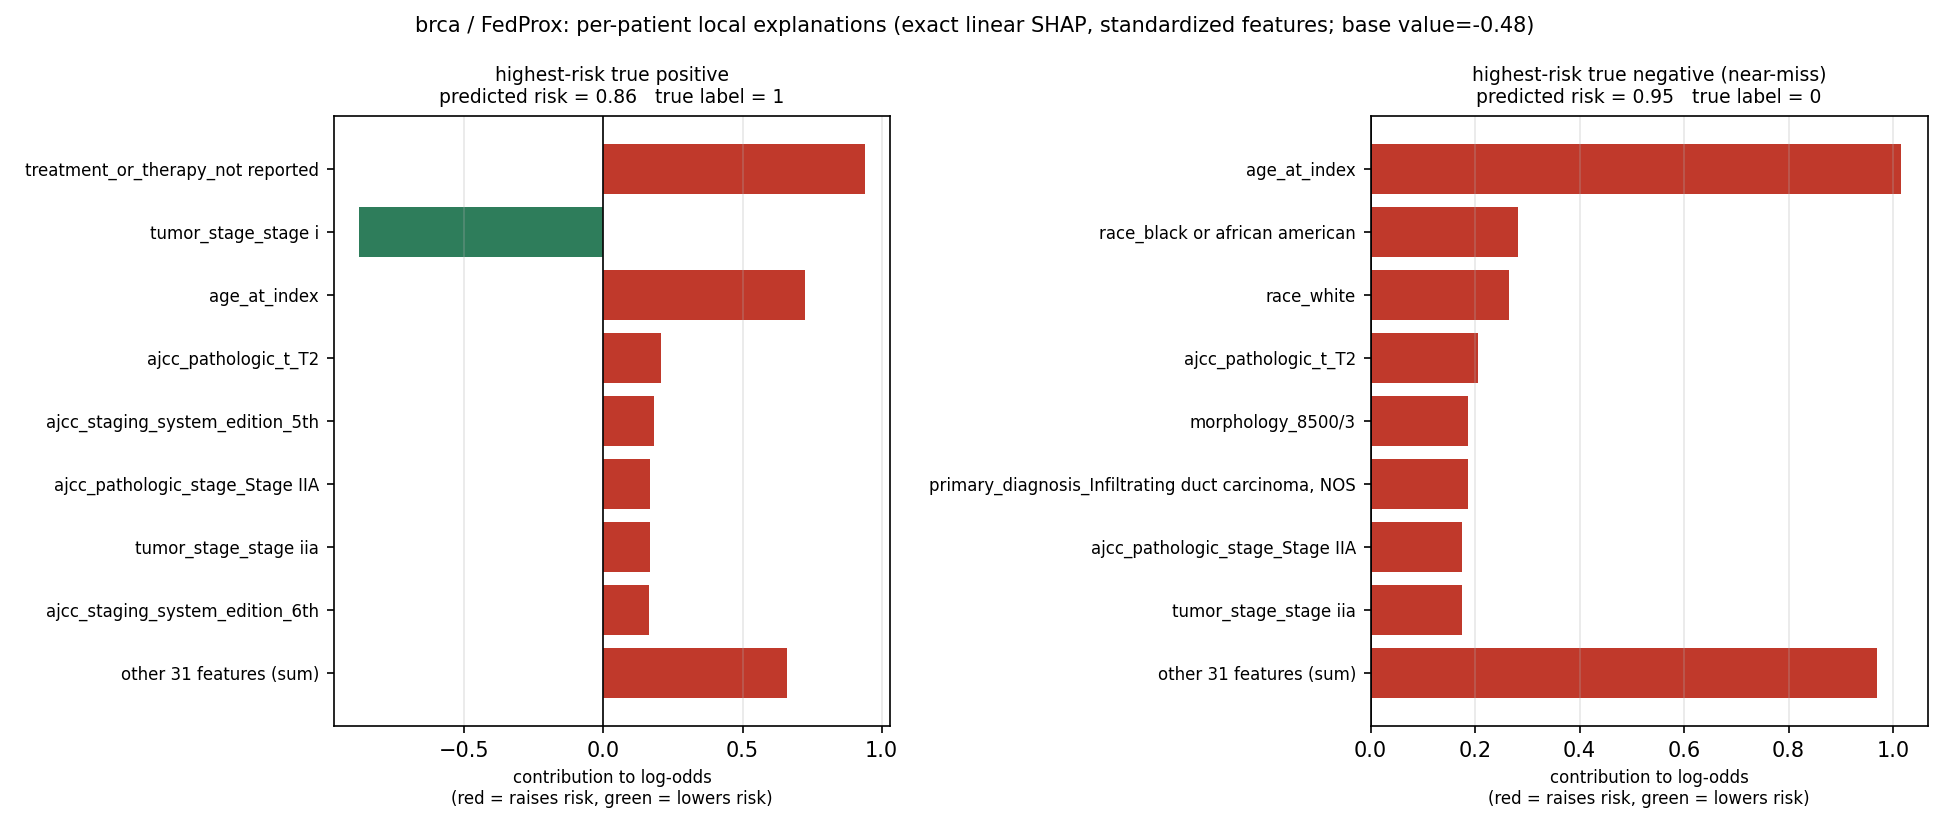

./qdp_fed_results/brca_fig_calibration.png


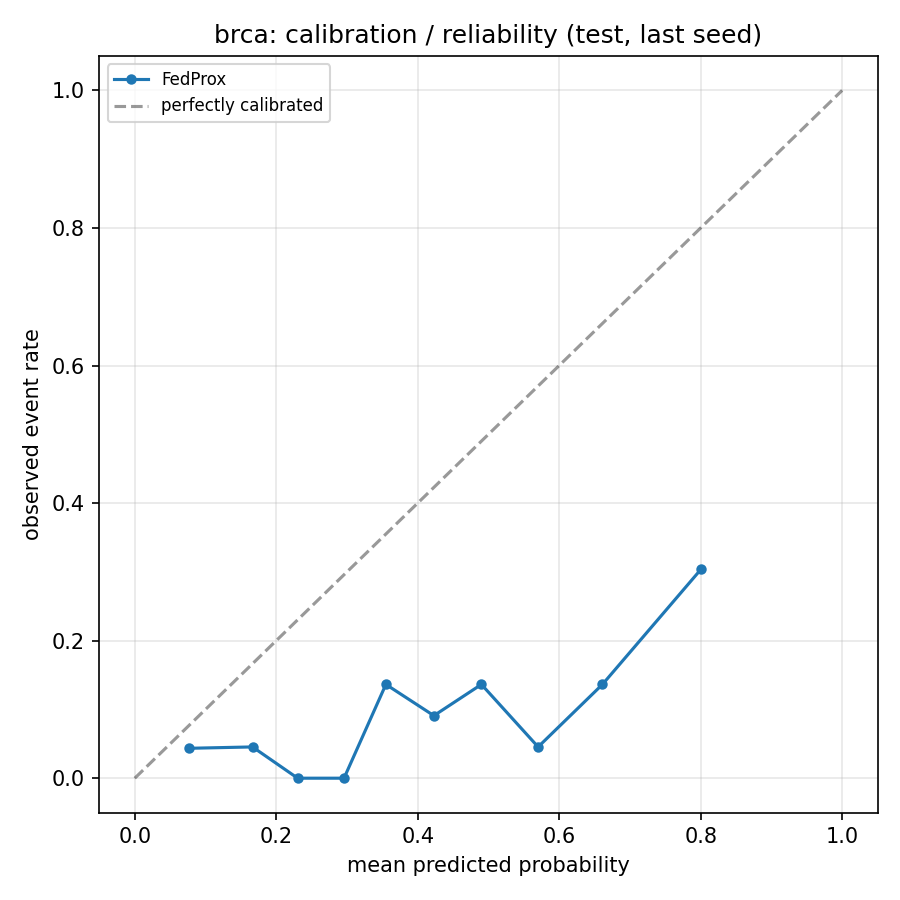

./qdp_fed_results/brca_fig_client_prevalence.png


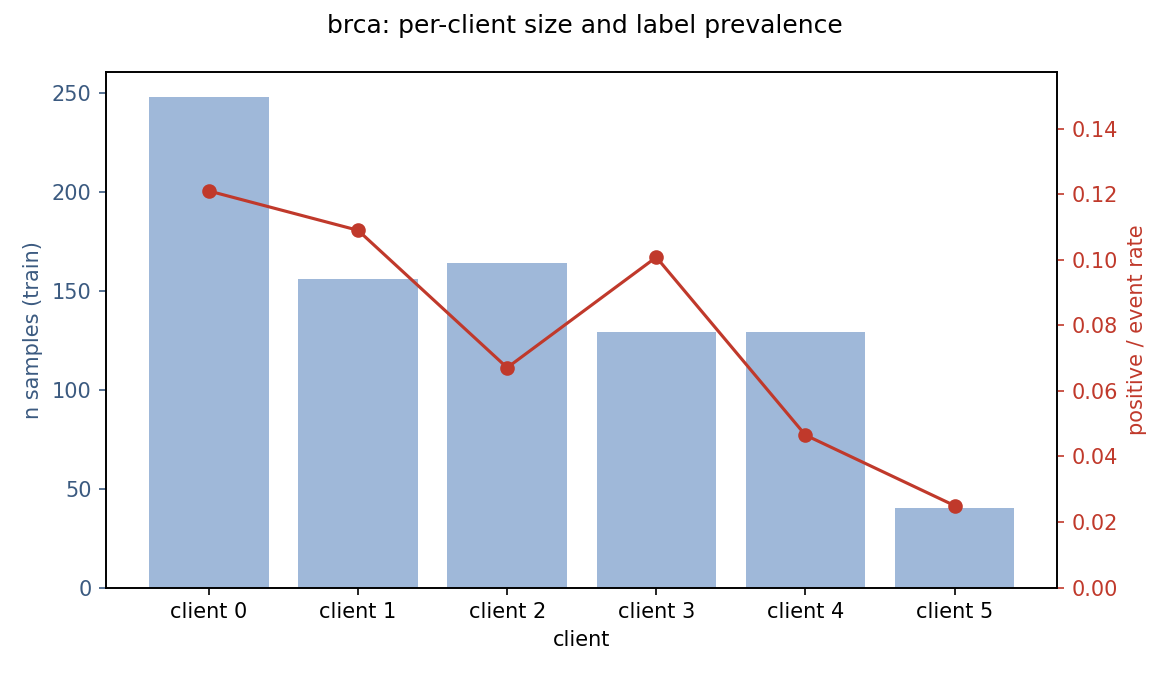

./qdp_fed_results/brca_fig_confusion_matrices.png


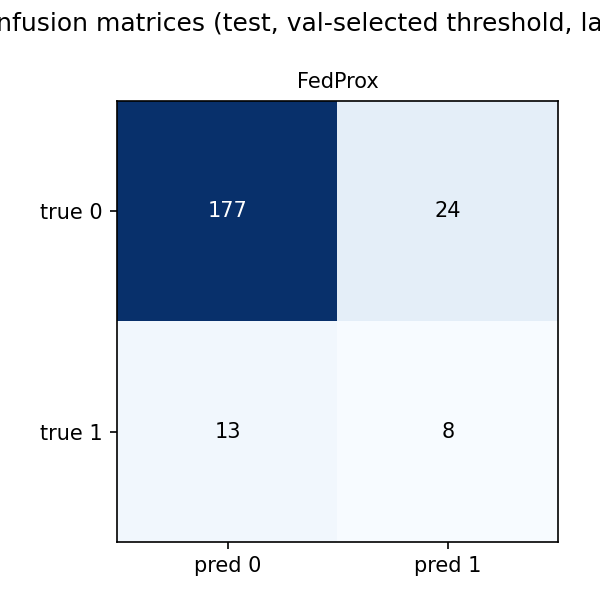

./qdp_fed_results/brca_fig_convergence.png


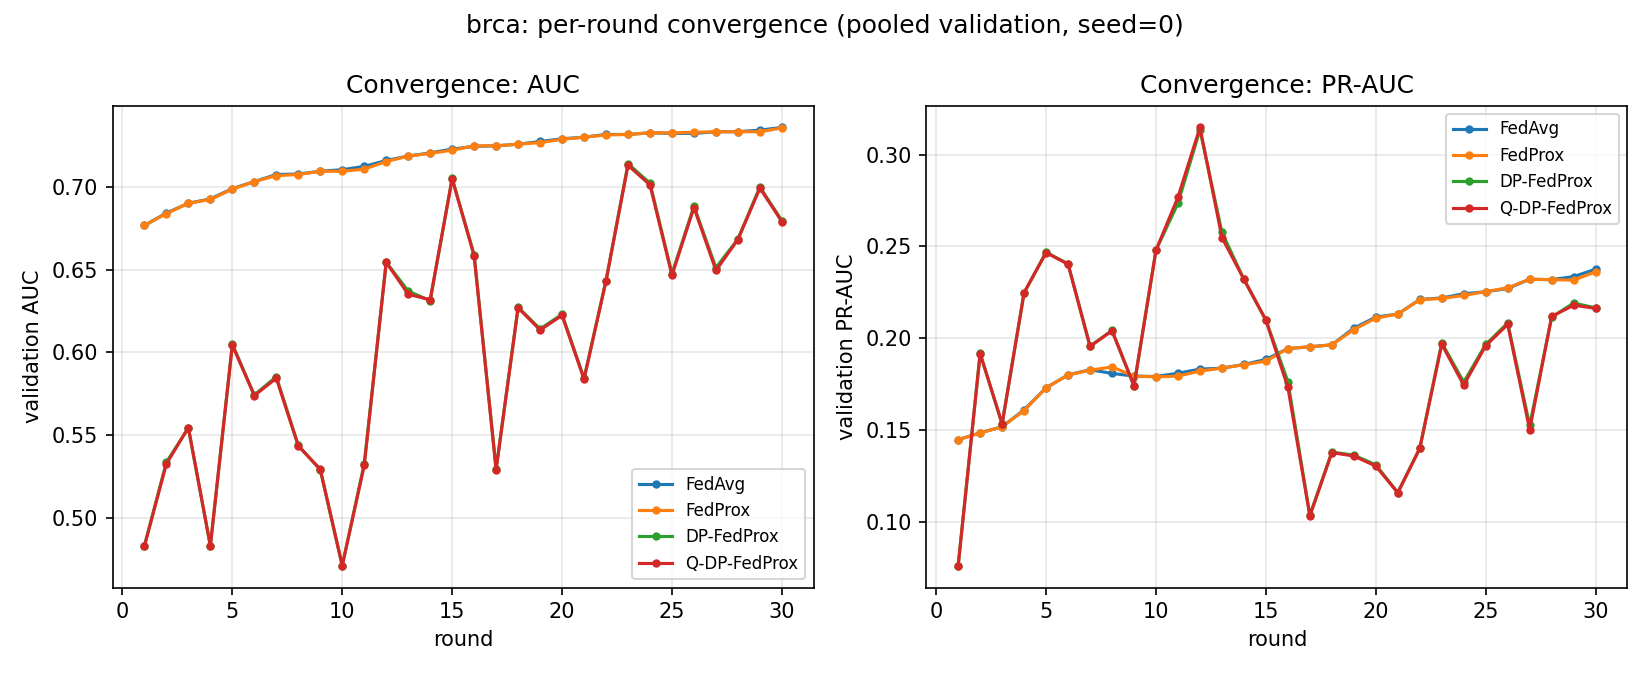

./qdp_fed_results/brca_fig_main_comparison.png


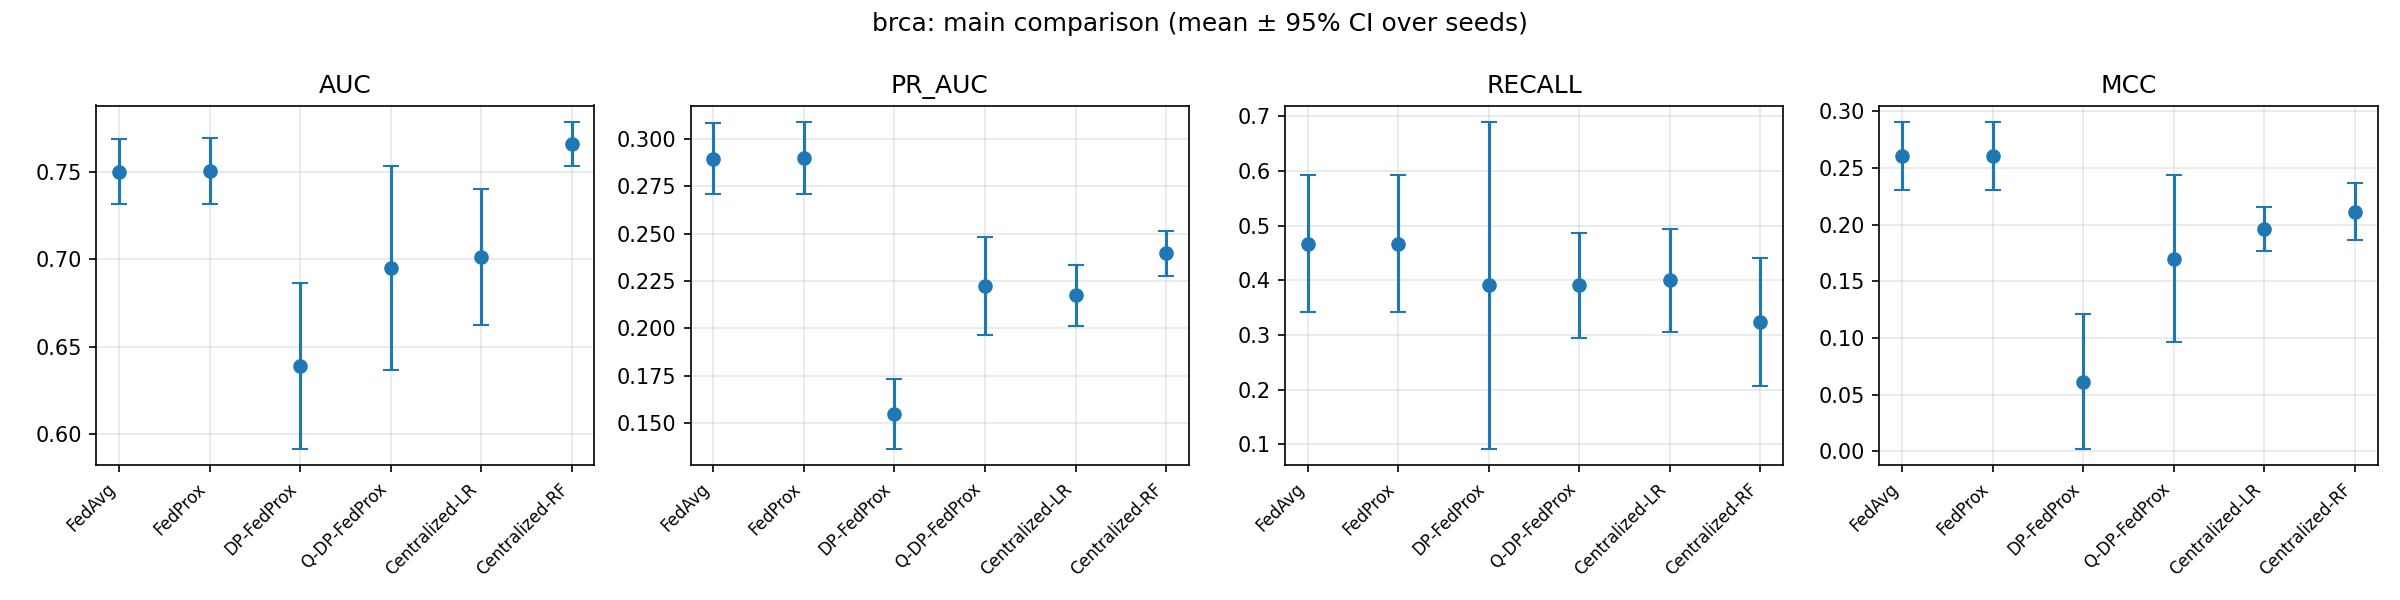

./qdp_fed_results/brca_fig_privacy_utility_comm.png


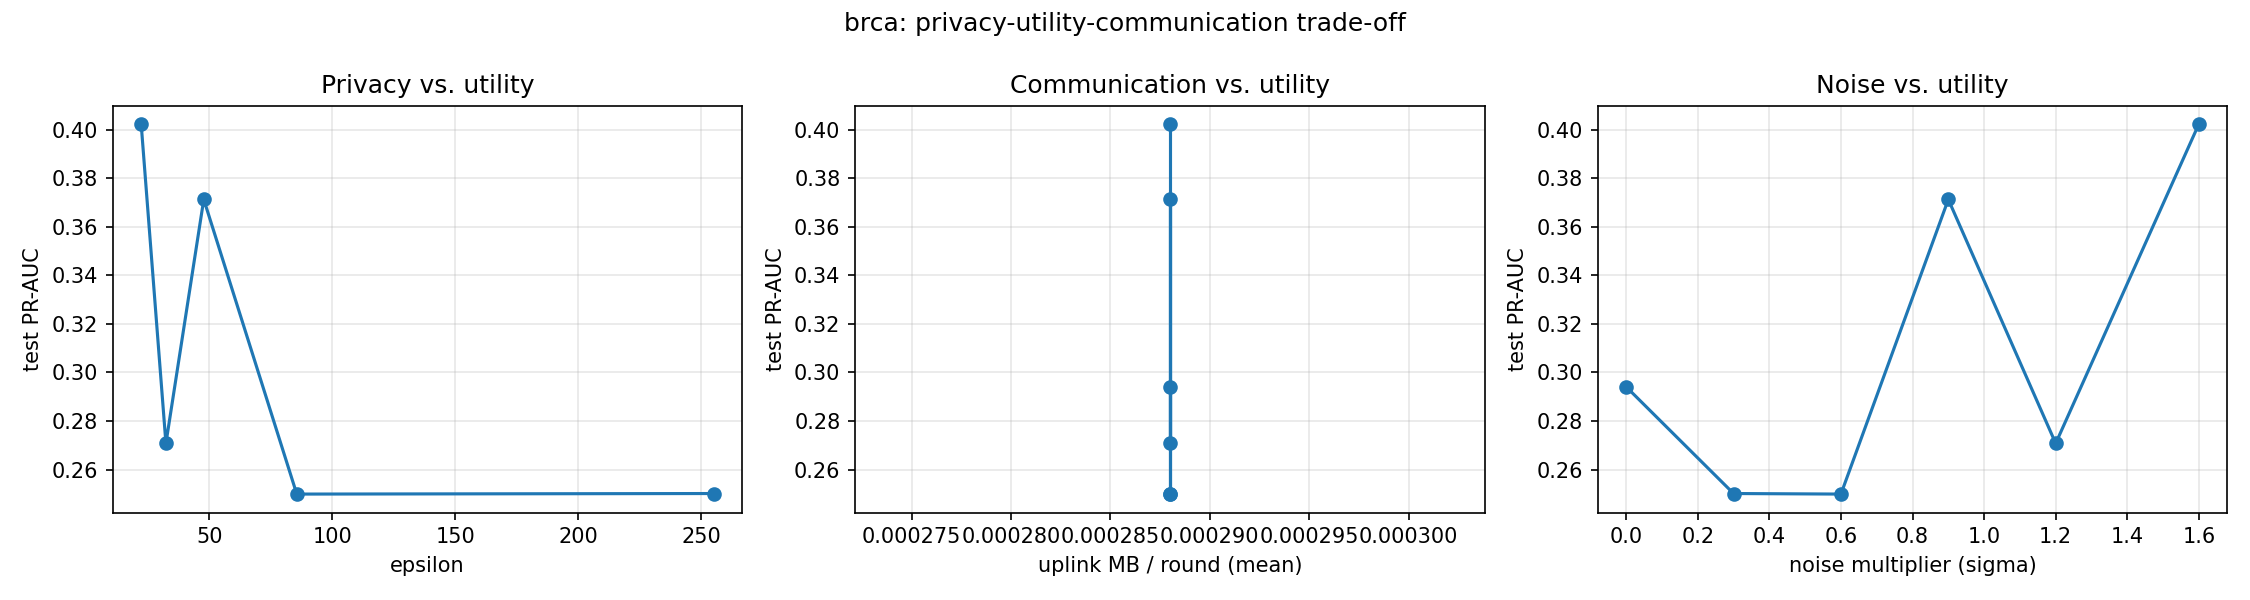

./qdp_fed_results/brca_fig_roc_curves.png


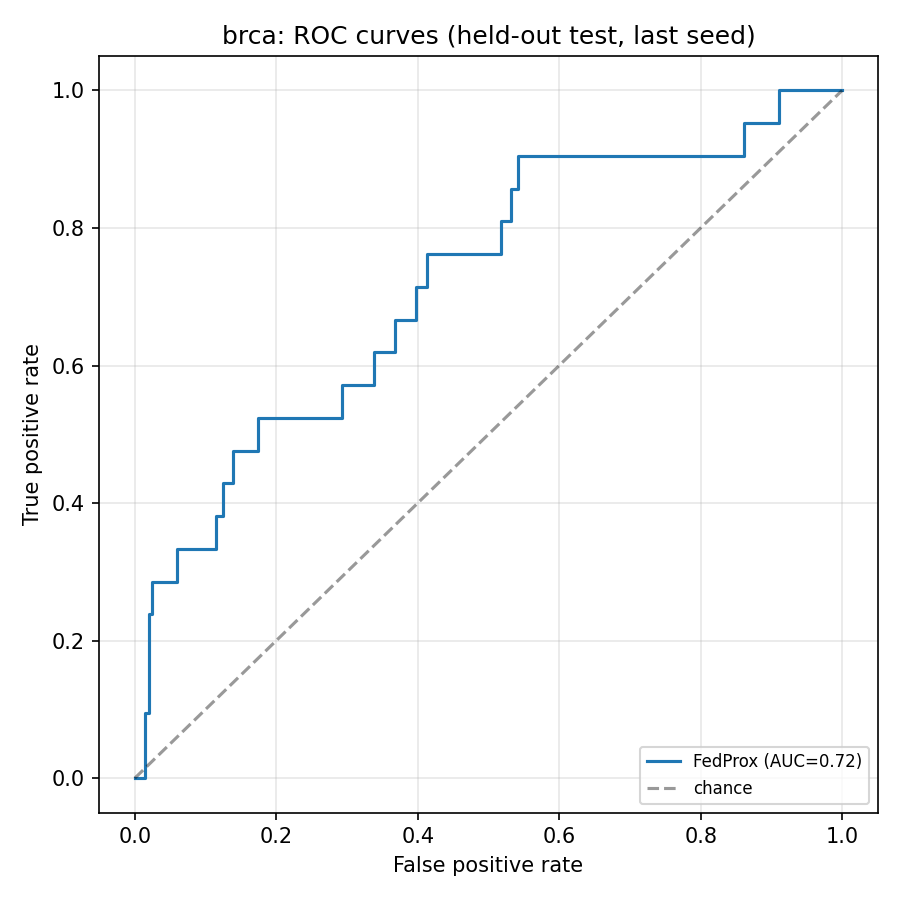

./qdp_fed_results/fig1_system_threat_model.png


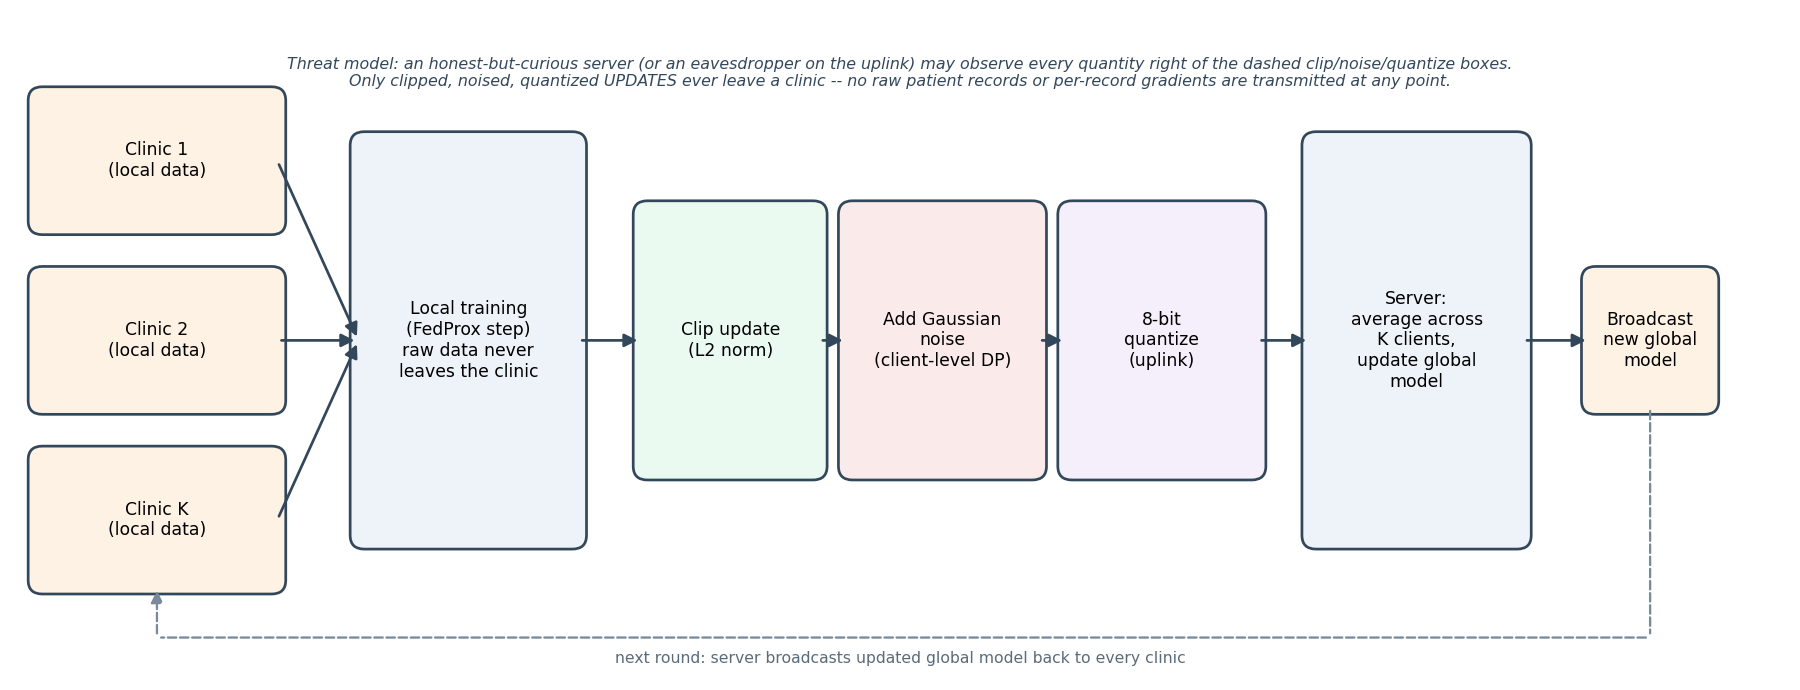

./qdp_fed_results/heart_FedProx_fig_local_explanations.png


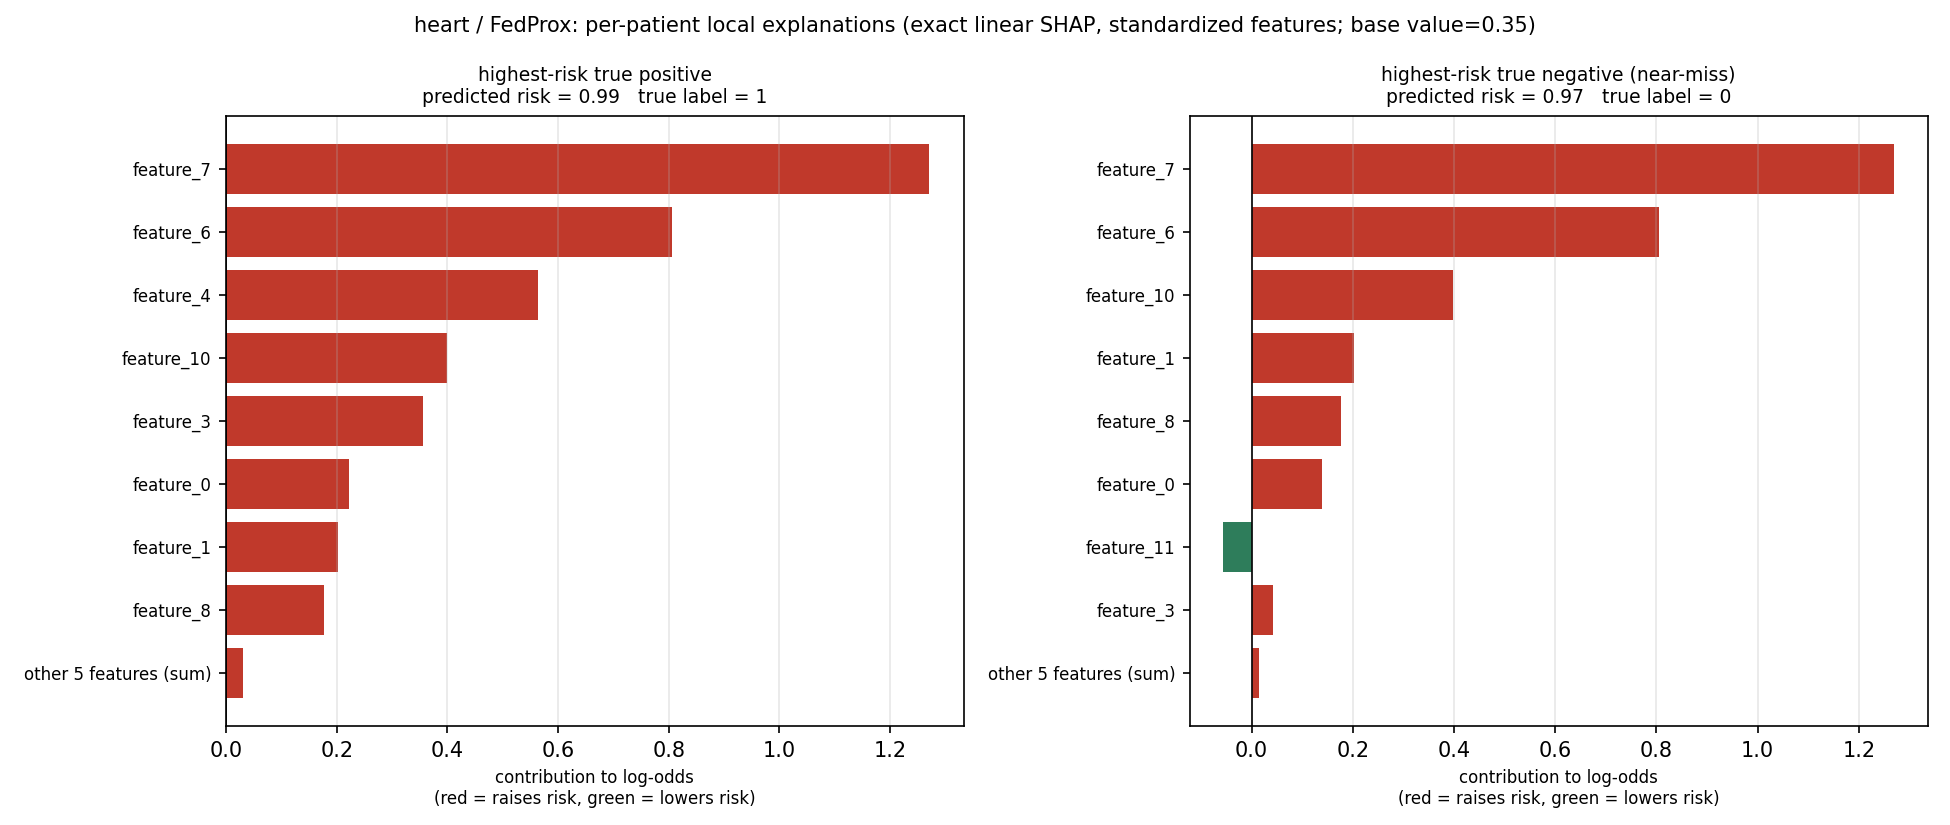

./qdp_fed_results/heart_fig_calibration.png


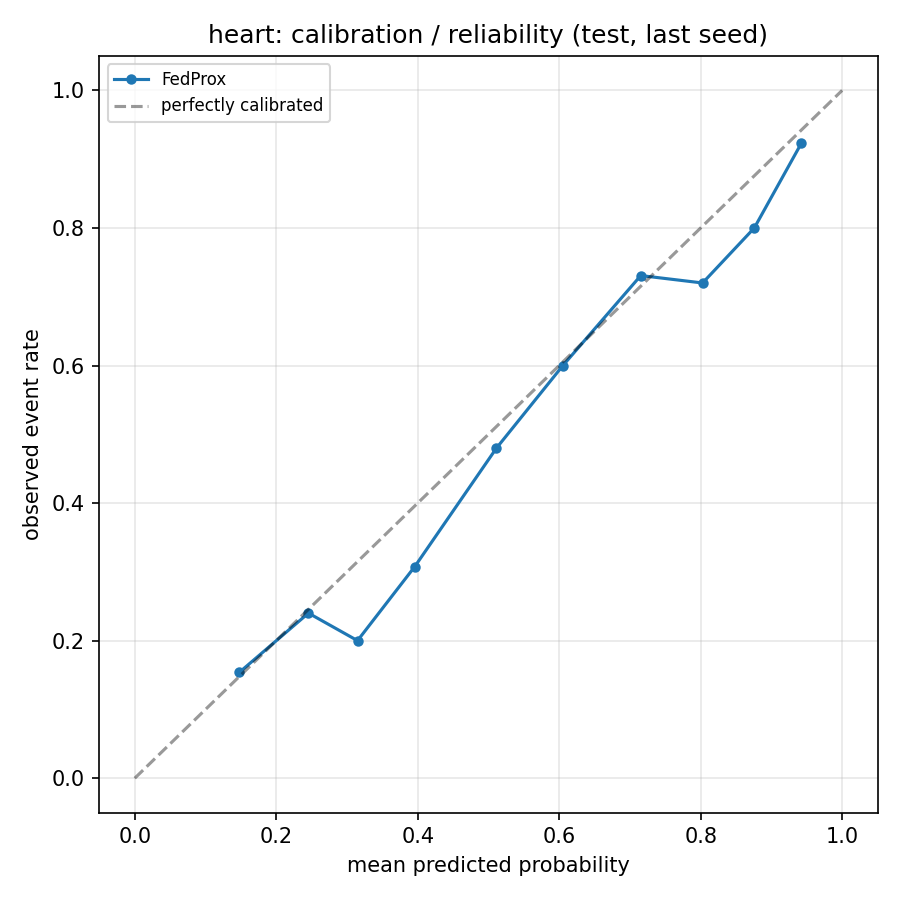

./qdp_fed_results/heart_fig_client_prevalence.png


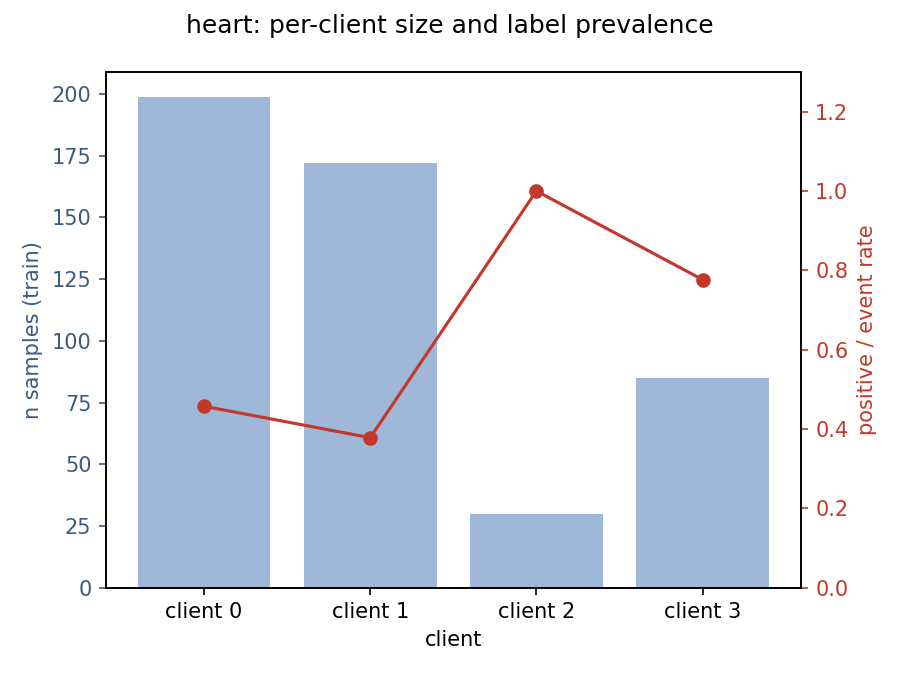

./qdp_fed_results/heart_fig_confusion_matrices.png


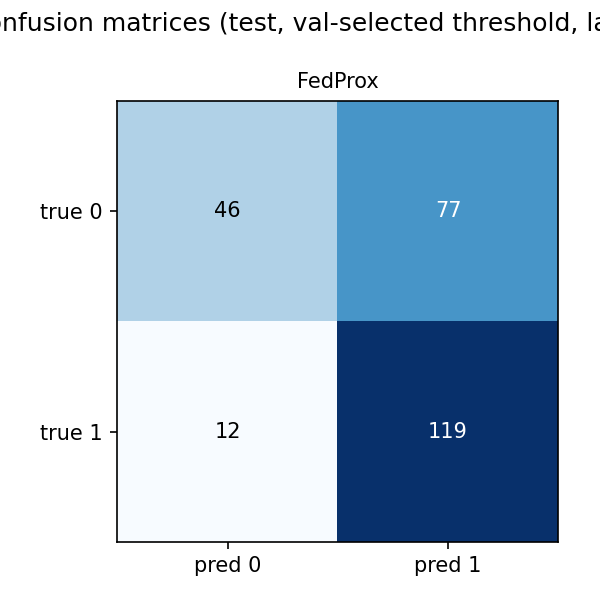

./qdp_fed_results/heart_fig_convergence.png


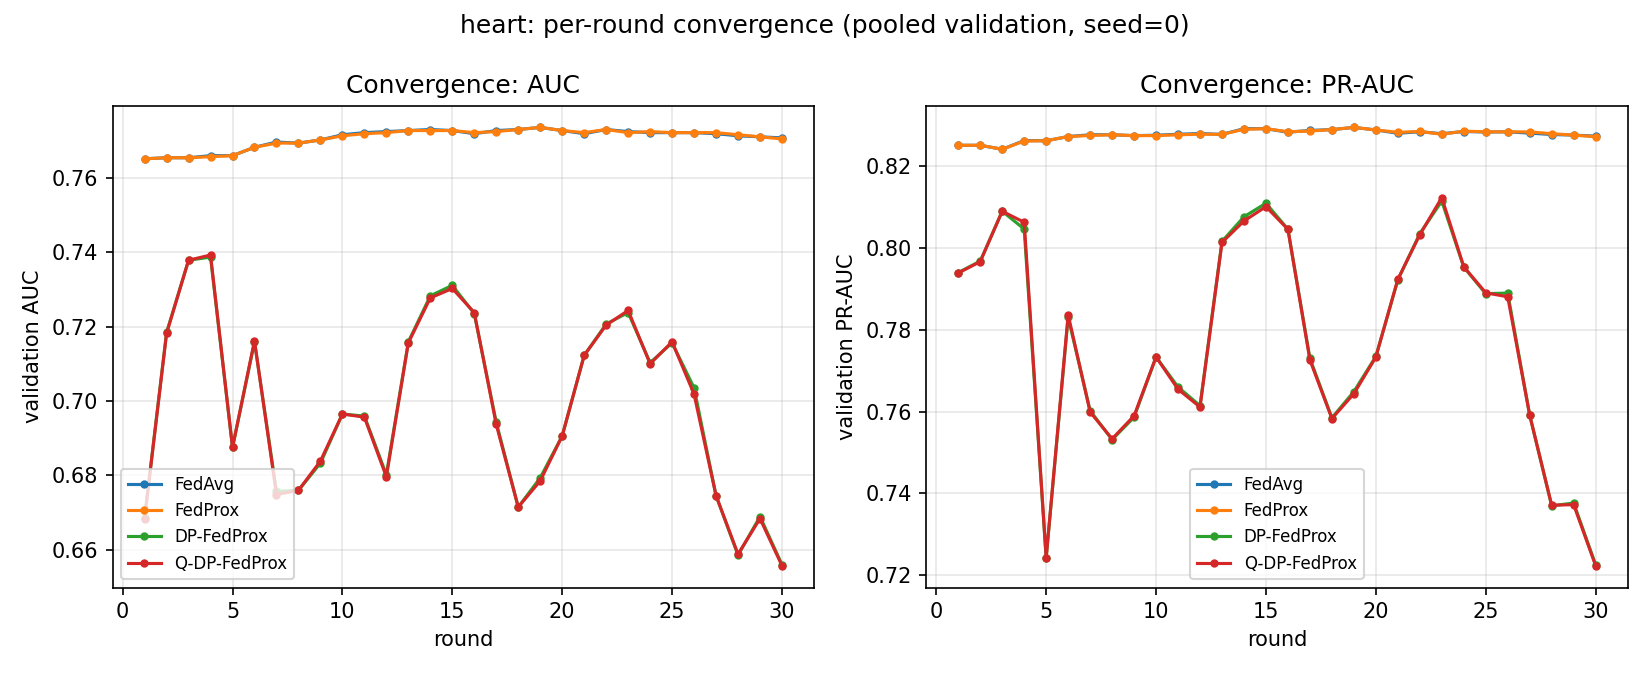

./qdp_fed_results/heart_fig_main_comparison.png


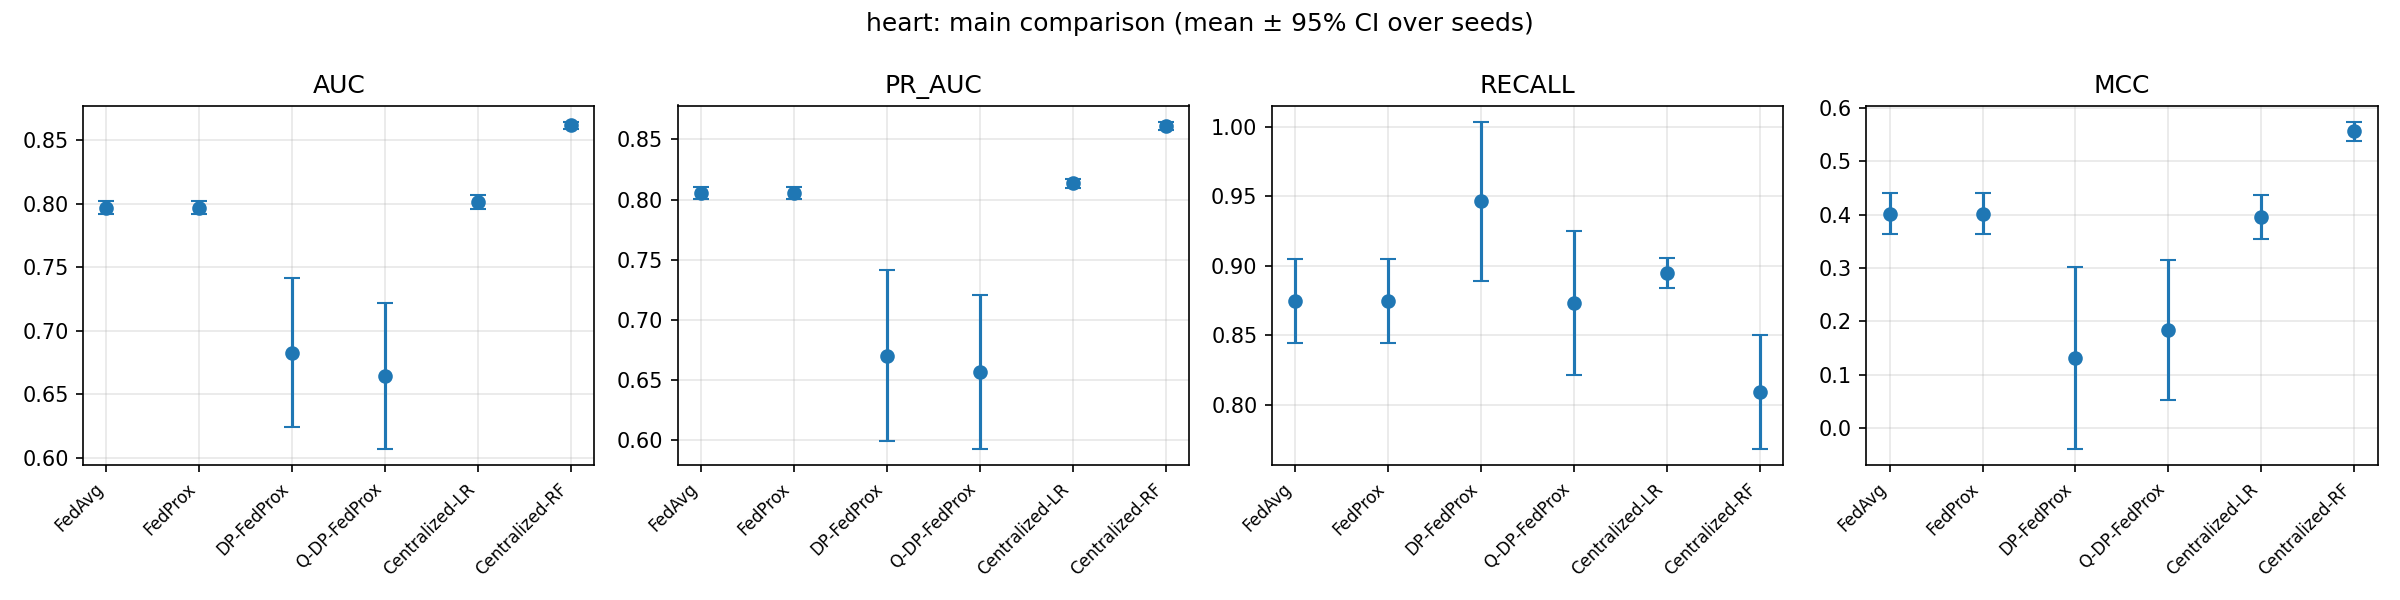

./qdp_fed_results/heart_fig_privacy_utility_comm.png


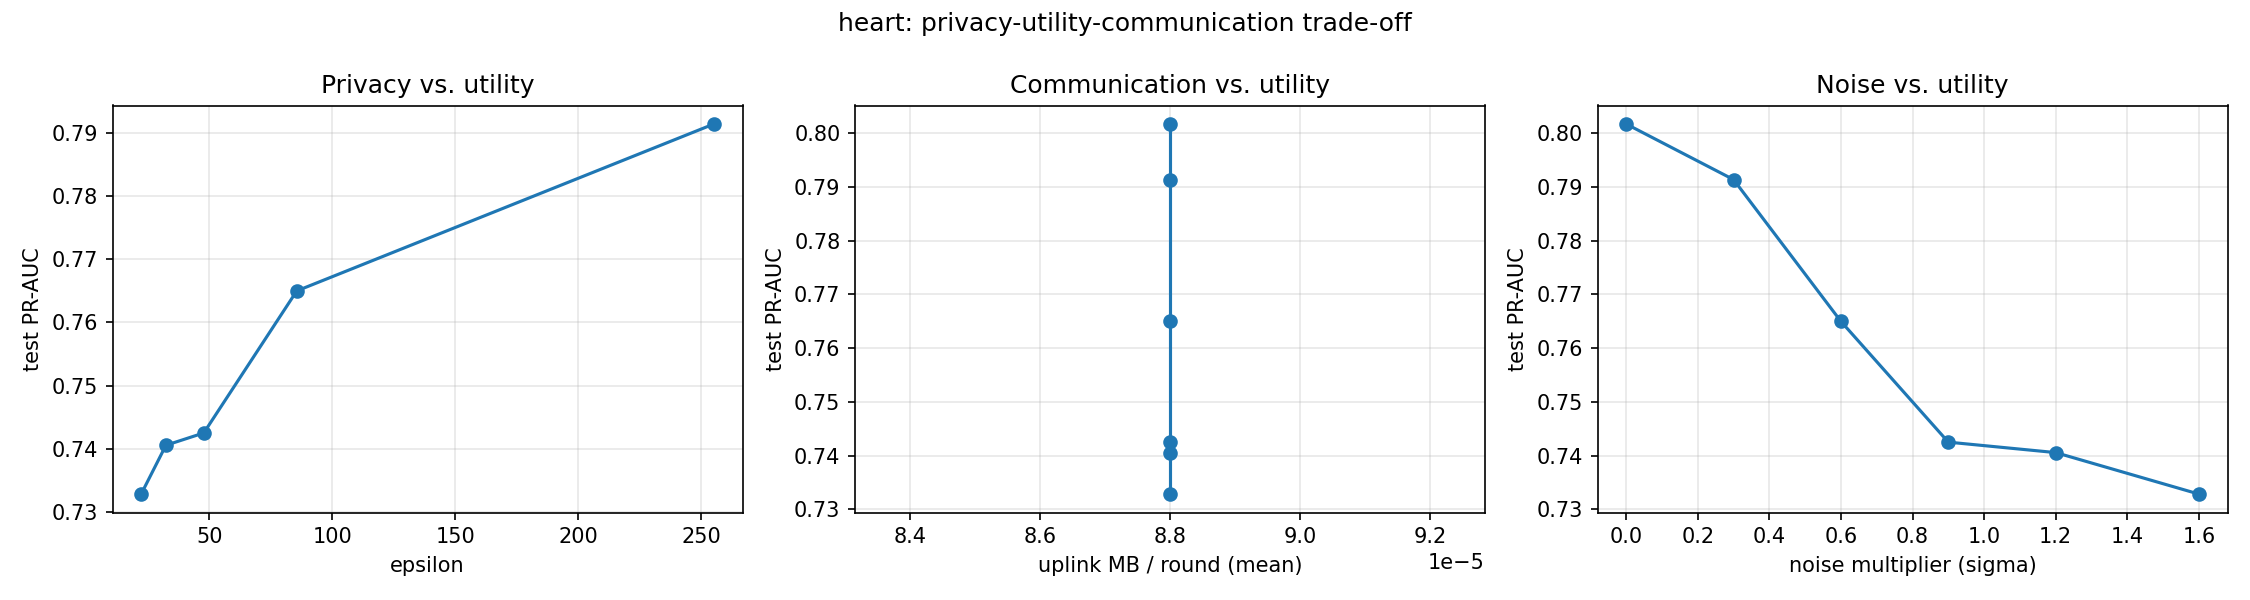

./qdp_fed_results/heart_fig_roc_curves.png


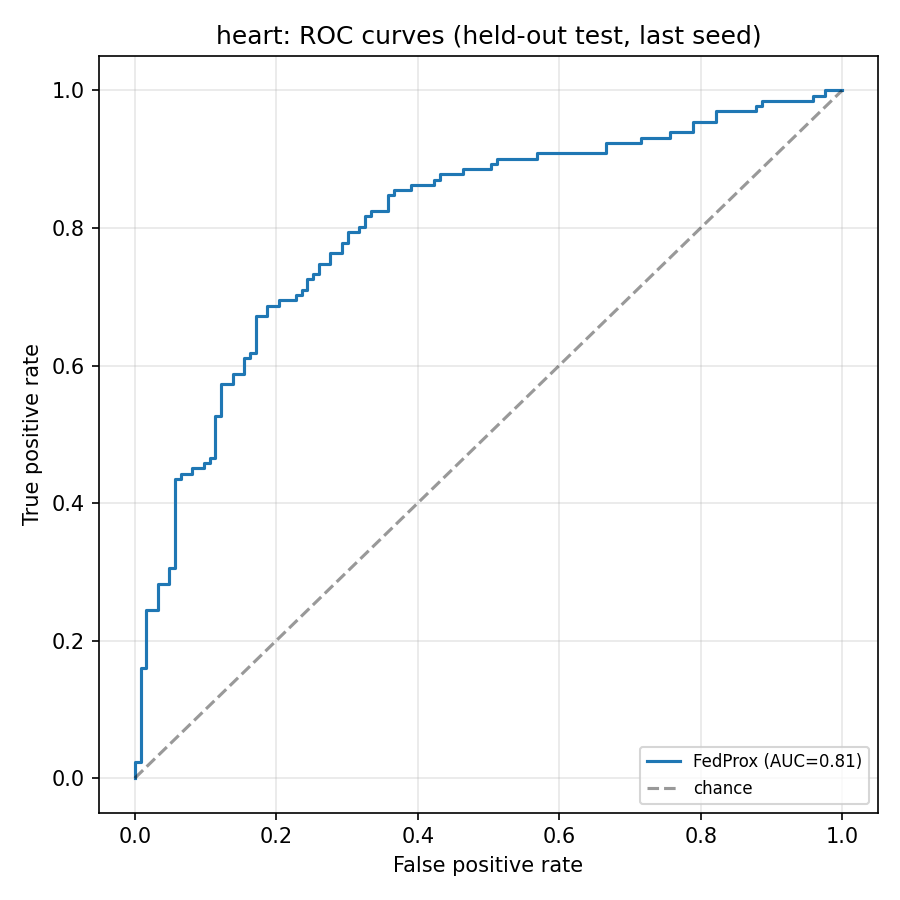

./qdp_fed_results/wisconsin_FedAvg_fig_local_explanations.png


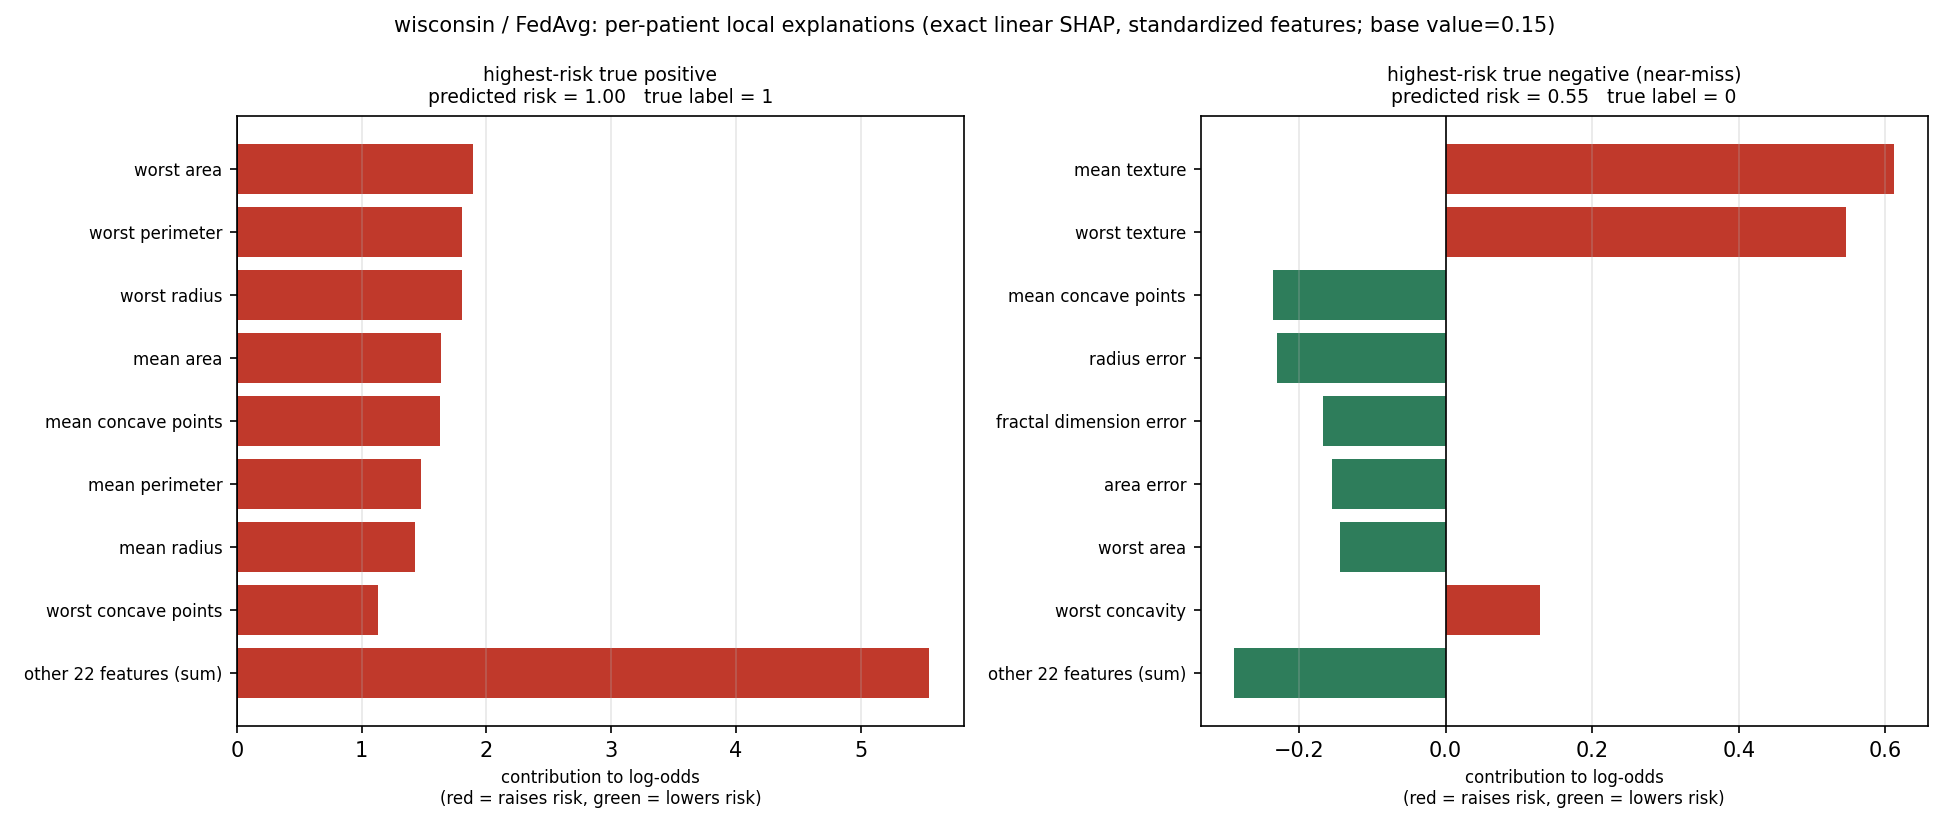

./qdp_fed_results/wisconsin_fig_calibration.png


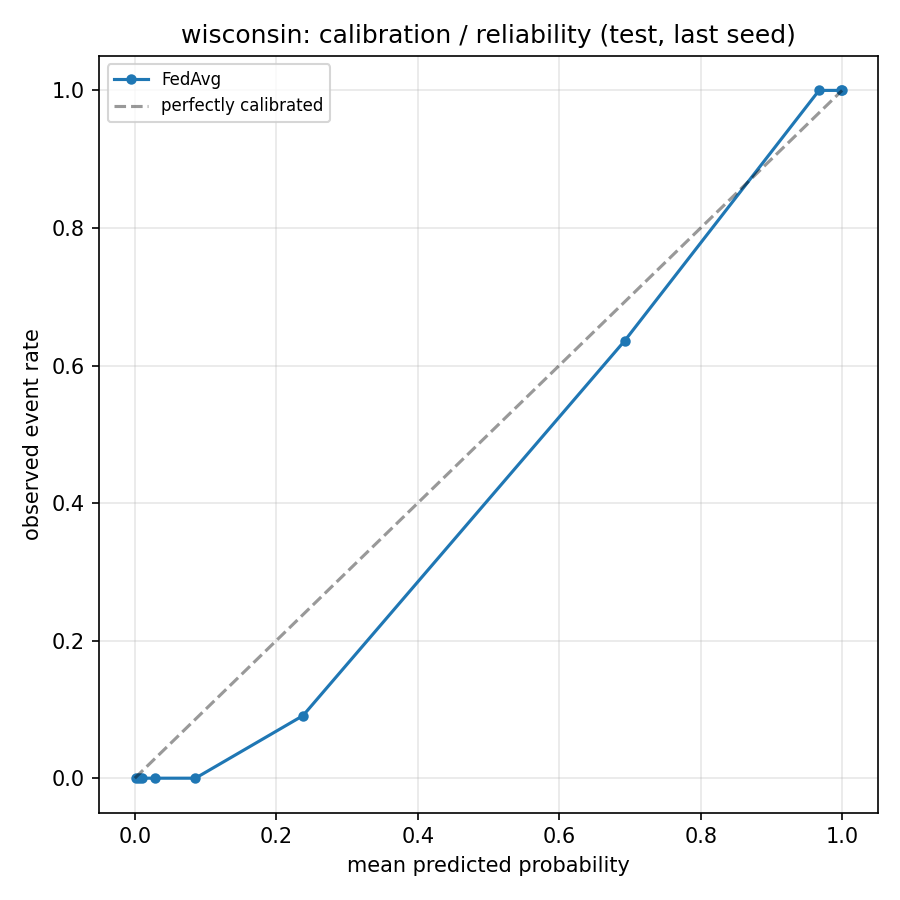

./qdp_fed_results/wisconsin_fig_client_prevalence.png


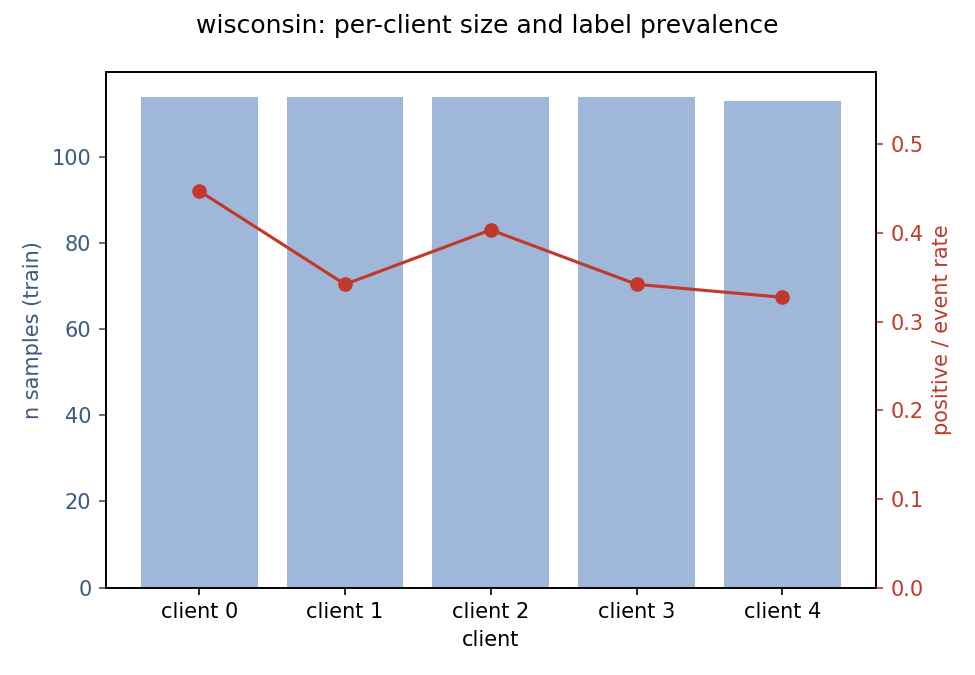

./qdp_fed_results/wisconsin_fig_confusion_matrices.png


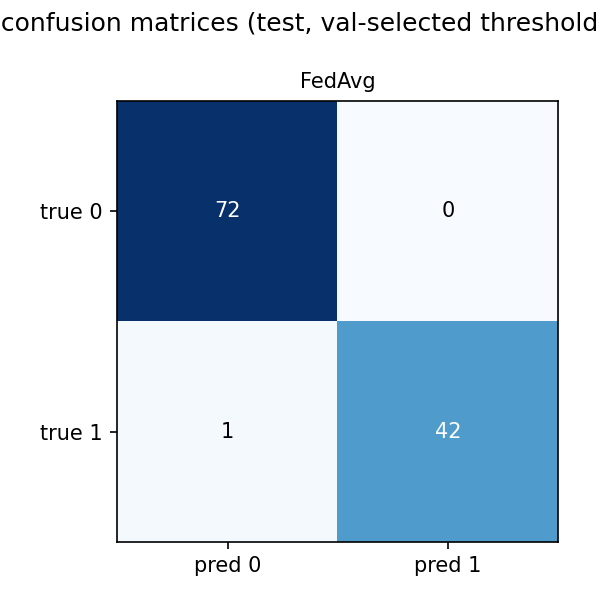

./qdp_fed_results/wisconsin_fig_convergence.png


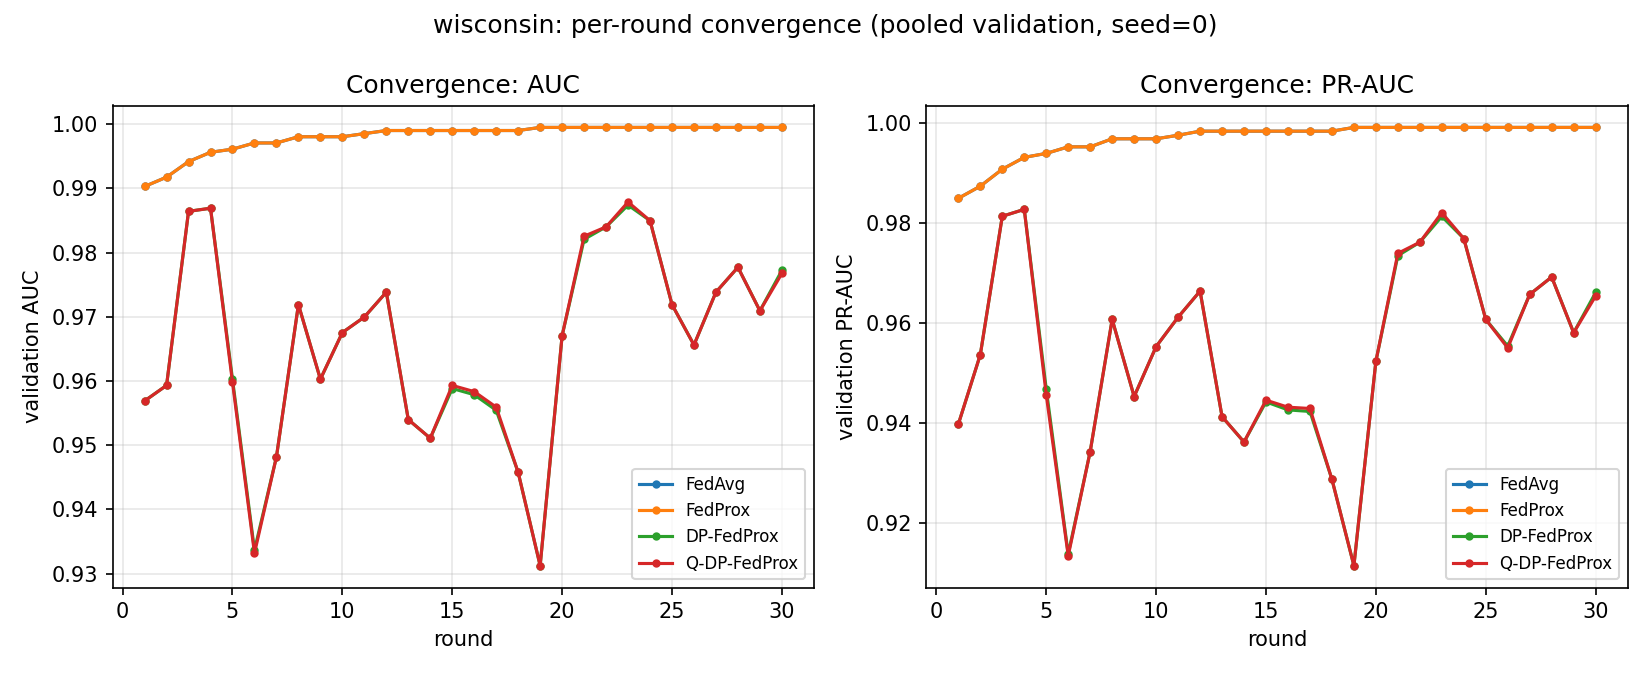

./qdp_fed_results/wisconsin_fig_main_comparison.png


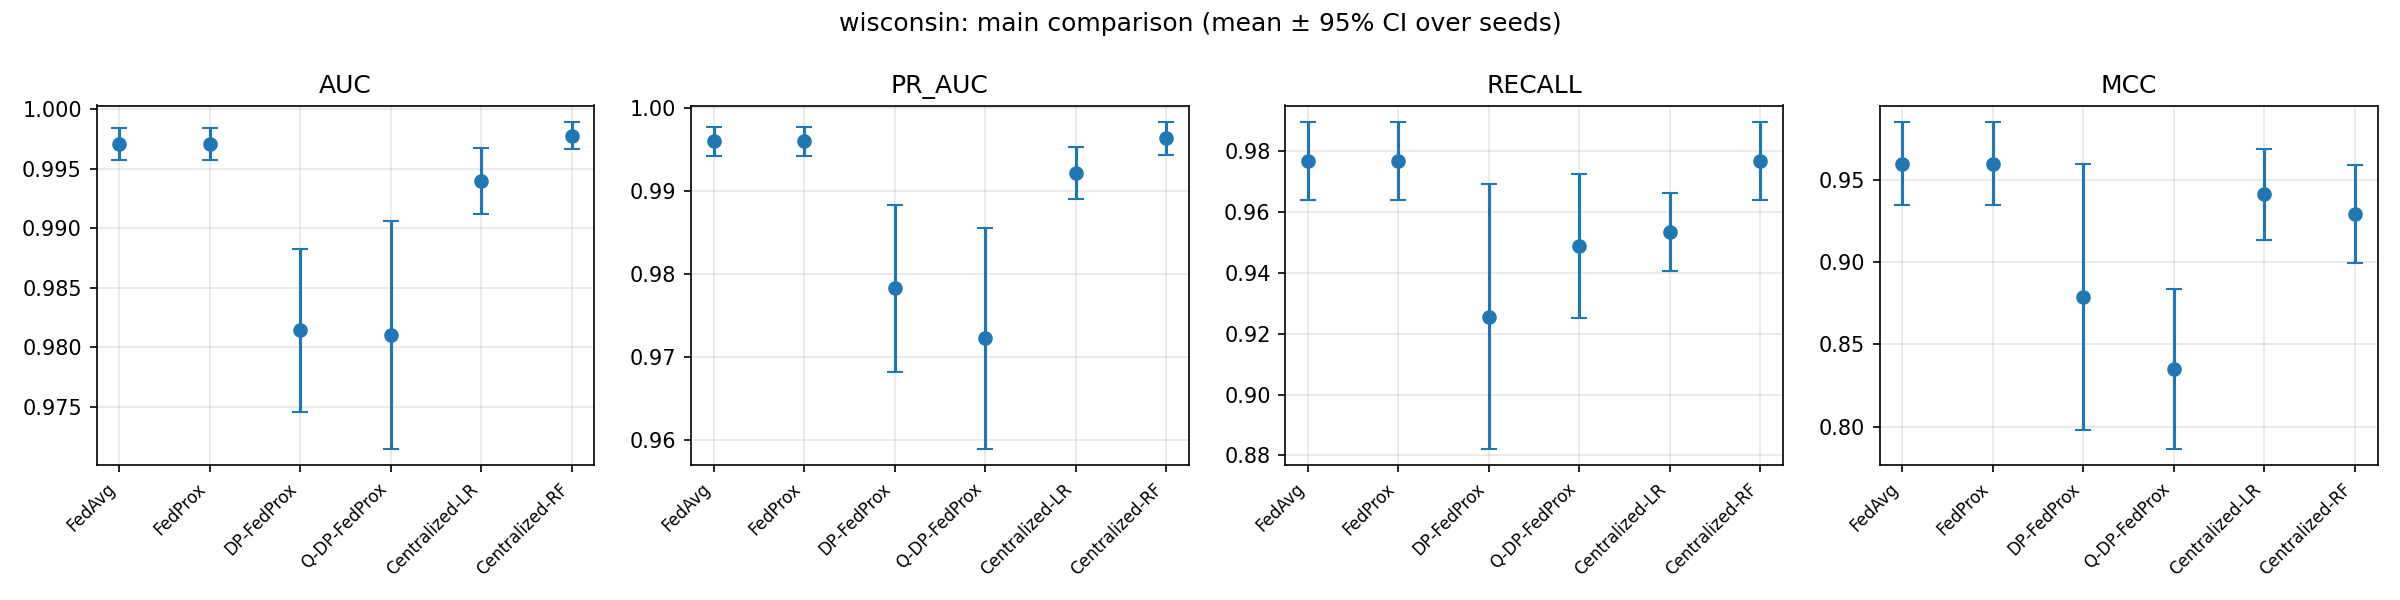

./qdp_fed_results/wisconsin_fig_noniid_robustness.png


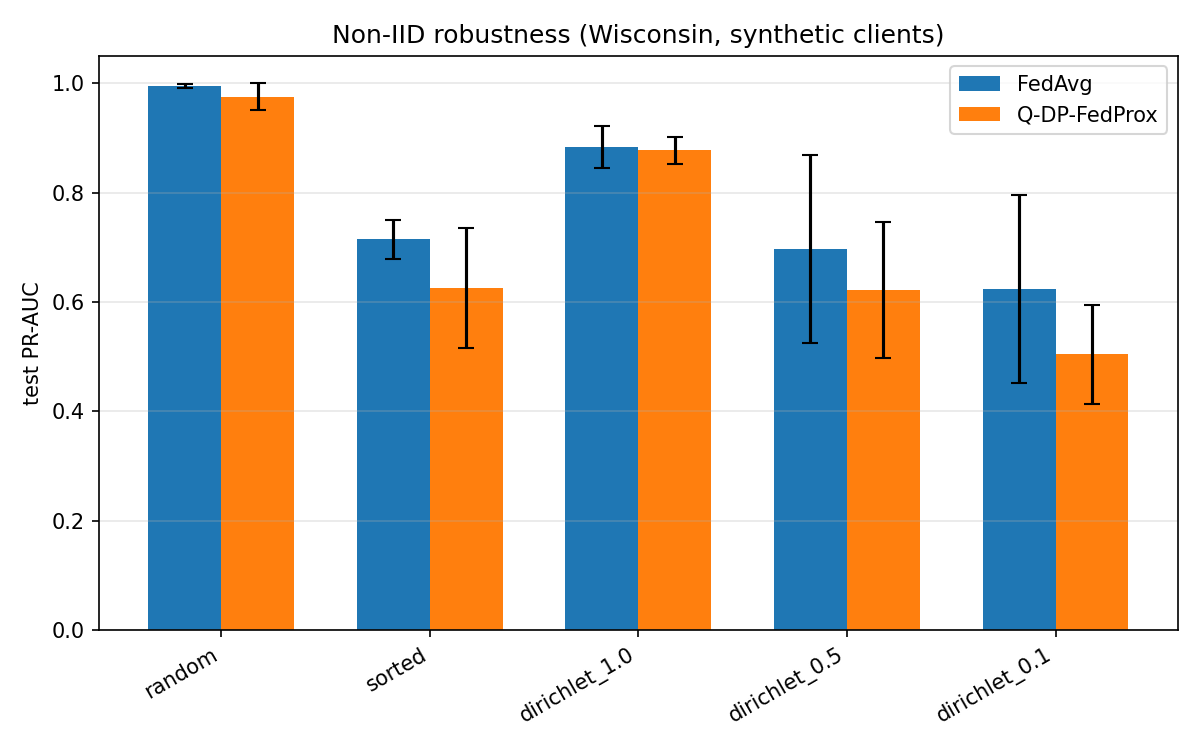

./qdp_fed_results/wisconsin_fig_roc_curves.png


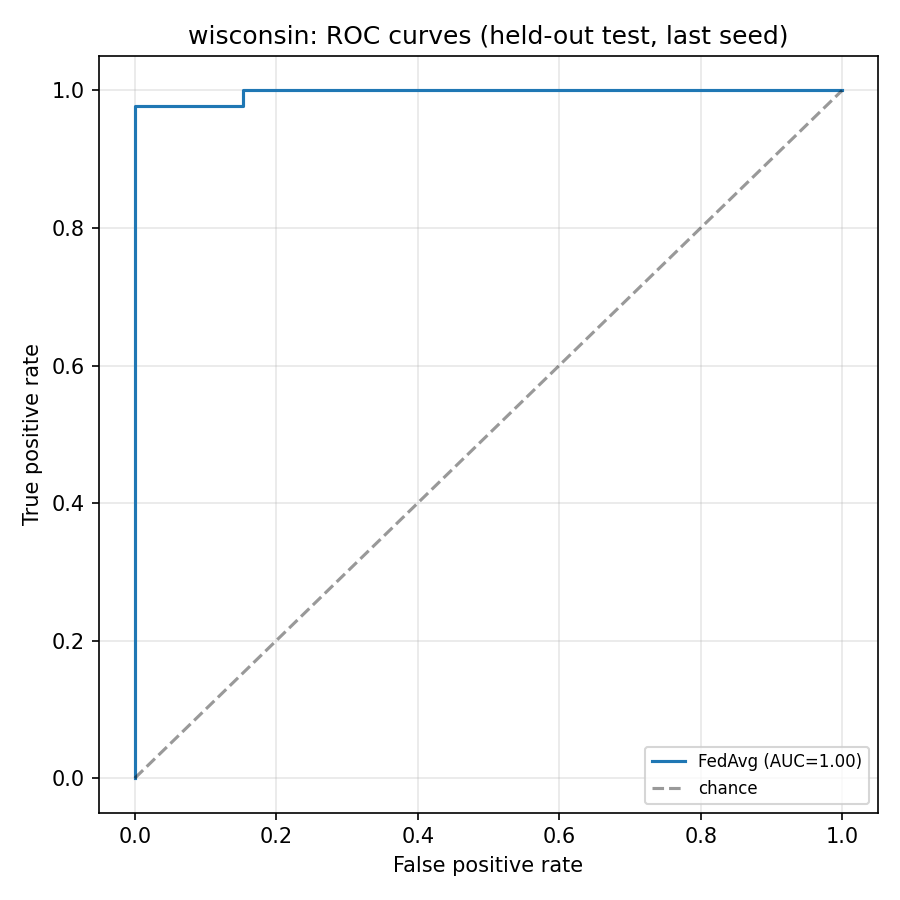

In [15]:
import shutil
from IPython.display import Image, display
import glob

shutil.make_archive("qdp_fed_results", "zip", "./qdp_fed_results")
print("Zipped to qdp_fed_results.zip")

# Since matplotlib uses the headless "Agg" backend, figures are saved
# straight to disk and never render inline automatically -- display them:
for f in sorted(glob.glob("./qdp_fed_results/*.png")):
    print(f)
    display(Image(f))